# EDA inicial - Requerimientos (No supervisado)

Objetivo: explorar calidad y estructura de datos para preparar un modelo no supervisado usando únicamente short_description y description.
Variables de fuga como assignment_group y assigned_to no se usarán para modelado.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
from pathlib import Path

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [4]:
# 1) Carga robusta del CSV objetivo (funciona desde raíz o desde Data)
from pathlib import Path
import pandas as pd

nombre_csv = "requerimientos_2026-05-28_17-09-55.csv"
cwd = Path.cwd()

candidatas = [
    cwd / nombre_csv,                    # si el notebook corre desde Data
    cwd / "Data" / nombre_csv,           # si corre desde la raíz del proyecto
    cwd.parent / "Data" / nombre_csv,    # si corre desde una subcarpeta (ej. Analisis/)
]

ruta_csv = next((p for p in candidatas if p.exists()), None)

if ruta_csv is None:
    buscados = "\n".join(str(p.resolve()) for p in candidatas)
    raise FileNotFoundError(f"No existe el archivo en ninguna ruta candidata:\n{buscados}")

print("Archivo seleccionado:", ruta_csv.resolve())

Archivo seleccionado: C:\ASIGNADOR\Asignador\Data\requerimientos_2026-05-28_17-09-55.csv


In [5]:
import random
from datetime import timedelta
from dateutil.relativedelta import relativedelta

df = pd.read_csv(
    ruta_csv,
    sep=";",
    encoding="latin-1",
    dtype=str,
    engine="python",
    on_bad_lines="skip"
)

# Fechas aleatorias de asignación para pruebas (rango: ene 2025 - jun 2026)
fecha_inicio = pd.Timestamp("2025-01-01")
fecha_fin    = pd.Timestamp("2026-06-04")
rango_dias   = (fecha_fin - fecha_inicio).days

rng = np.random.default_rng(seed=42)
df["fecha_asignacion"] = pd.to_datetime(
    rng.integers(0, rango_dias, size=len(df)), unit="D", origin=fecha_inicio
)
print(df[["number", "fecha_asignacion"]].head(10))


print("Dimensiones:", df.shape)
display(df.head(3))
print("\nColumnas:")
print(df.columns.tolist())


        number fecha_asignacion
0  RITM0716416       2025-02-16
1  RITM0620071       2026-02-06
2  RITM0754745       2025-12-06
3  RITM0795775       2025-08-16
4  RITM0424331       2025-08-13
5  RITM0709362       2026-03-22
6  RITM0658358       2025-02-14
7  RITM0594481       2025-12-28
8  RITM0625900       2025-04-15
9  RITM0741342       2025-02-18
Dimensiones: (11216, 14)


,number,state,ref_sc_req_item.requested_for,requested_for.vip,requested_for.email,requested_for.title,requested_for.company,assigned_to,assignment_group,short_description,cat_item.sc_catalogs,description,u_variables_texto,fecha_asignacion
0,RITM0716416,Cerrado,ANGELA MERCEDES OBANDO BERNAL,falso,amobando@pichincha.com,EJECUTIVO BACK Y SERVICIOS,Banco Pichincha C.A.,KONERI DAMODARAM,TEC_TCS_BANCS,Requerimientos de información relacionados a B...,TI,Estimados su gentil ayuda con el cambio de es...,NaN,2025-02-16
1,RITM0620071,Cerrado,JHOSUE DAVID BRITO ASTUDILLO,falso,jbritoas@pichincha.com,SOPORTE ADMINISTRATIVO,Banco Pichincha C.A.,MARCELA YADIRA ZUNIGA UBILLUZ,TEC_TCS_BANCS,Requerimientos de información relacionados a B...,TI,¿Cómo se genera la información del archivo de ...,NaN,2026-02-06
2,RITM0754745,Cerrado,XIOMARA ELIZABETH CEVALLOS TENORIO,falso,xecevall@pichincha.com,EJECUTIVO COMERCIAL RELACIONAL,Banco Pichincha C.A.,LEONELA JACKELINE DELGADO MENDIETA,TEC_TCS_BANCS,Requerimientos de información relacionados a B...,TI,¿Buenos días por favor su ayuda con revisión a...,NaN,2025-12-06



Columnas:
['number', 'state', 'ref_sc_req_item.requested_for', 'requested_for.vip', 'requested_for.email', 'requested_for.title', 'requested_for.company', 'assigned_to', 'assignment_group', 'short_description', 'cat_item.sc_catalogs', 'description', 'u_variables_texto', 'fecha_asignacion']


In [6]:
# Pre-clasificación por regla: Alivios Financieros
# Se aplica sobre texto crudo para no depender del pipeline de limpieza

texto_raw_lower = (
    df['short_description'].fillna('') + ' ' + df['description'].fillna('')
).str.lower()

texto_raw_original = (
    df['short_description'].fillna('') + ' ' + df['description'].fillna('')
)

mask_alivio = (
    texto_raw_lower.str.contains(r'\bdiferimiento\b', regex=True) |
    texto_raw_lower.str.contains(r'normaliz', regex=True)
)
mask_bancs_test = texto_raw_original.str.contains('BANCS TEST', case=True)

df['es_alivio_financiero'] = mask_alivio & ~mask_bancs_test

print(f"Tickets 'alivios_financieros' (cluster fijo):  {df['es_alivio_financiero'].sum()}")
print(f"  └─ Con 'BANCS TEST' → van al K-Means:        {(mask_alivio & mask_bancs_test).sum()}")
print(f"Tickets para K-Means:                          {(~df['es_alivio_financiero']).sum()}")


Tickets 'alivios_financieros' (cluster fijo):  107
  └─ Con 'BANCS TEST' → van al K-Means:        14
Tickets para K-Means:                          11109


In [7]:
# Diagnóstico: tickets con diferimiento/retención que pasaron al K-Means
texto_raw_lower    = (df['short_description'].fillna('') + ' ' + df['description'].fillna('')).str.lower()
texto_raw_original = (df['short_description'].fillna('') + ' ' + df['description'].fillna(''))

mask_diferimiento = texto_raw_lower.str.contains(r'\bdiferimiento\b', regex=True)
mask_retencion    = texto_raw_lower.str.contains(r'\bretencion\b|retención', regex=True)
mask_bancs_test   = texto_raw_original.str.contains('BANCS TEST', case=True)

# Cuántos hay en total
print(f"Tickets con 'diferimiento':               {mask_diferimiento.sum()}")
print(f"  → marcados como alivio financiero:      {(mask_diferimiento & df['es_alivio_financiero']).sum()}")
print(f"  → pasaron al K-Means (con BANCS TEST):  {(mask_diferimiento & mask_bancs_test).sum()}")
print(f"  → pasaron al K-Means (sin BANCS TEST):  {(mask_diferimiento & ~df['es_alivio_financiero'] & ~mask_bancs_test).sum()}")

print()
print(f"Tickets con 'retención':                  {mask_retencion.sum()}")
print(f"  → capturados por filtro alivios:        {(mask_retencion & df['es_alivio_financiero']).sum()}")
print(f"  → pasaron al K-Means:                   {(mask_retencion & ~df['es_alivio_financiero']).sum()}")

# Mostrar ejemplos de diferimientos que se escaparon
escapados = df[mask_diferimiento & ~df['es_alivio_financiero'] & ~mask_bancs_test]
if len(escapados) > 0:
    print(f"\nEjemplos de 'diferimiento' que escaparon el filtro ({len(escapados)} tickets):")
    for _, row in escapados.head(5).iterrows():
        print(f"\n  [{row['number']}]")
        print(f"  short: {row['short_description']}")
        print(f"  desc:  {str(row['description'])[:200]}")


Tickets con 'diferimiento':               26
  → marcados como alivio financiero:      26
  → pasaron al K-Means (con BANCS TEST):  0
  → pasaron al K-Means (sin BANCS TEST):  0

Tickets con 'retención':                  78
  → capturados por filtro alivios:        0
  → pasaron al K-Means:                   78


In [8]:
# 2) Definir columnas para modelado no supervisado
cols_texto = ["short_description", "description"]
faltantes = [c for c in cols_texto if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas críticas: {faltantes}")

# Solo dejamos columnas útiles para esta fase
cols_base = [c for c in ["number", "state"] if c in df.columns] + cols_texto
df_eda = df[cols_base].copy()

print("Columnas en df_eda:", df_eda.columns.tolist())
print("Registros:", len(df_eda))
display(df_eda.head(3))

Columnas en df_eda: ['number', 'state', 'short_description', 'description']
Registros: 11216


,number,state,short_description,description
0,RITM0716416,Cerrado,Requerimientos de información relacionados a B...,Estimados su gentil ayuda con el cambio de es...
1,RITM0620071,Cerrado,Requerimientos de información relacionados a B...,¿Cómo se genera la información del archivo de ...
2,RITM0754745,Cerrado,Requerimientos de información relacionados a B...,¿Buenos días por favor su ayuda con revisión a...


In [9]:
# 3) Calidad de datos de texto: nulos, vacíos, cardinalidad

def es_vacio(x):
    if pd.isna(x):
        return True
    s = str(x).strip().lower()
    return s in {"", "nan", "none", "null"}

resumen_calidad = []
for c in cols_texto:
    vacios = df_eda[c].apply(es_vacio).sum()
    resumen_calidad.append({
        "columna": c,
        "n_registros": len(df_eda),
        "n_vacios": int(vacios),
        "pct_vacios": round(vacios / len(df_eda) * 100, 2),
        "n_unicos_no_nulos": int(df_eda[c].nunique(dropna=True))
    })

resumen_calidad = pd.DataFrame(resumen_calidad)
display(resumen_calidad)

,columna,n_registros,n_vacios,pct_vacios,n_unicos_no_nulos
0,short_description,11216,0,0.0,32
1,description,11216,1323,11.8,9264


In [10]:
# 4) Construir texto unificado SOLO con short_description + description
df_eda["texto_unificado_raw"] = (
    df_eda["short_description"].fillna("").astype(str).str.strip() + " " +
    df_eda["description"].fillna("").astype(str).str.strip()
).str.replace(r"\s+", " ", regex=True).str.strip()

df_eda["texto_vacio"] = df_eda["texto_unificado_raw"].eq("")

print("Registros sin texto útil:", int(df_eda["texto_vacio"].sum()))
print("Porcentaje sin texto útil:", round(df_eda["texto_vacio"].mean() * 100, 2), "%")
display(df_eda[["texto_unificado_raw", "texto_vacio"]].head(5))

Registros sin texto útil: 0
Porcentaje sin texto útil: 0.0 %


,texto_unificado_raw,texto_vacio
0,Requerimientos de información relacionados a B...,False
1,Requerimientos de información relacionados a B...,False
2,Requerimientos de información relacionados a B...,False
3,Requerimientos de información relacionados a B...,False
4,Requerimientos de información relacionados a B...,False


In [11]:
# 5) Duplicados exactos (muy importante para clustering)
dup_pair = df_eda[cols_texto].fillna("").duplicated(keep=False)
dup_texto = df_eda["texto_unificado_raw"].duplicated(keep=False)

print("Duplicados por (short_description, description):", int(dup_pair.sum()))
print("Duplicados por texto_unificado_raw:", int(dup_texto.sum()))

# Muestra de ejemplos duplicados
ej_dup = df_eda.loc[dup_texto, ["number", "short_description", "description", "texto_unificado_raw"]].head(10)
display(ej_dup)

Duplicados por (short_description, description): 2244
Duplicados por texto_unificado_raw: 2289


,number,short_description,description,texto_unificado_raw
6,RITM0658358,Requerimientos de información relacionados a B...,Versionar el proceso dev_check.sh y posterior ...,Requerimientos de información relacionados a B...
7,RITM0594481,Requerimientos de información relacionados a B...,Versionar el proceso dev_check.sh y posterior ...,Requerimientos de información relacionados a B...
8,RITM0625900,Requerimientos de información relacionados a B...,Versionar el proceso dev_check.sh y posterior ...,Requerimientos de información relacionados a B...
36,RITM0725104,Requerimientos de información relacionados a B...,Ver movimientos de BANCS para el incidente INC...,Requerimientos de información relacionados a B...
37,RITM0718982,Requerimientos de información relacionados a B...,Ver movimientos de BANCS para el incidente INC...,Requerimientos de información relacionados a B...
63,RITM0698508,Requerimientos de información relacionados a B...,Ver movimientos de BANCS para el incidente INC...,Requerimientos de información relacionados a B...
64,RITM0698553,Requerimientos de información relacionados a B...,Ver movimientos de BANCS para el incidente INC...,Requerimientos de información relacionados a B...
71,RITM0698520,Requerimientos de información relacionados a B...,Ver movimientos de BANCS para el incidente INC...,Requerimientos de información relacionados a B...
72,RITM0698567,Requerimientos de información relacionados a B...,Ver movimientos de BANCS para el incidente INC...,Requerimientos de información relacionados a B...
167,RITM0826292,Requerimientos de información relacionados a B...,Test: Por favor su ayuda para la obtención de ...,Requerimientos de información relacionados a B...


          len_chars     len_words
count  11216.000000  11216.000000
mean     287.924572     43.879101
std      237.605444     32.774219
min       13.000000      2.000000
25%      178.000000     27.000000
50%      257.000000     39.000000
75%      343.000000     55.000000
90%      482.000000     75.000000
95%      592.000000     91.000000
99%     1031.700000    148.850000
max    12446.000000   1224.000000


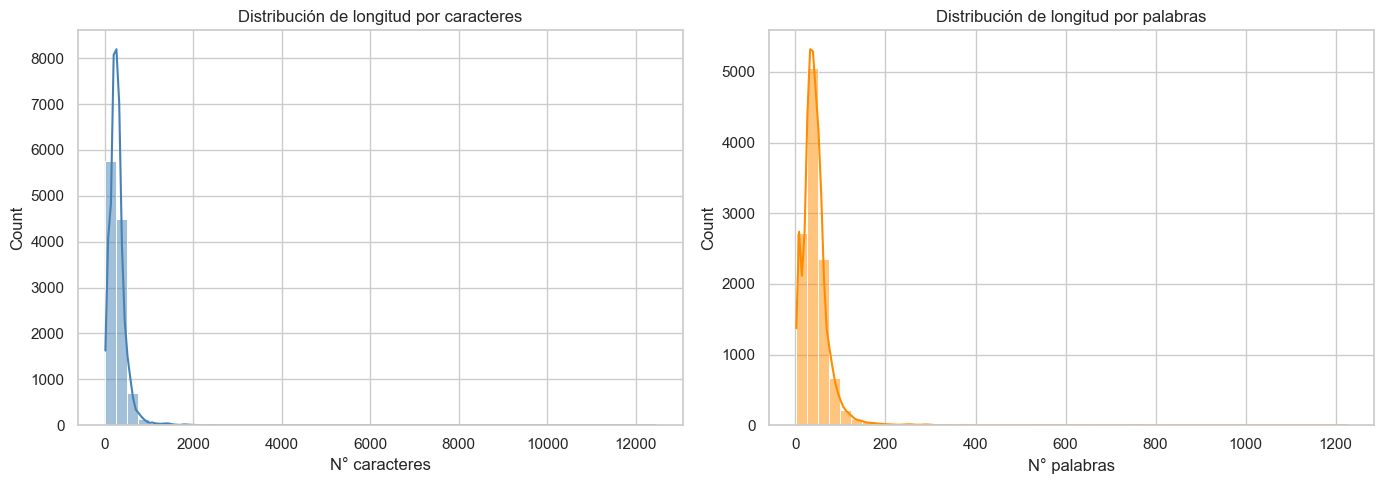

In [12]:
# 6) Longitud del texto: chars y palabras
df_len = df_eda.loc[~df_eda["texto_vacio"]].copy()
df_len["len_chars"] = df_len["texto_unificado_raw"].str.len()
df_len["len_words"] = df_len["texto_unificado_raw"].str.split().str.len()

print(df_len[["len_chars", "len_words"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_len["len_chars"], bins=50, kde=True, ax=ax[0], color="steelblue")
ax[0].set_title("Distribución de longitud por caracteres")
ax[0].set_xlabel("N° caracteres")

sns.histplot(df_len["len_words"], bins=50, kde=True, ax=ax[1], color="darkorange")
ax[1].set_title("Distribución de longitud por palabras")
ax[1].set_xlabel("N° palabras")

plt.tight_layout()
plt.show()

In [13]:
# 7) Señal de "plantillas" repetitivas en short_description
top_short = (
    df_eda["short_description"]
    .fillna("VACIO")
    .astype(str)
    .str.strip()
    .value_counts()
    .head(15)
)

print("Top 15 short_description más frecuentes:")
display(top_short.to_frame("frecuencia"))

Top 15 short_description más frecuentes:


,frecuencia
short_description,
Requerimientos de información relacionados a Bancs y BancsLink,10723
Atención solicitudes Bancs y BancsLinks,399
Procesos Batch,20
Requerimientos de Información Mantenimiento,13
Requerimientos para facturación estados de cuenta,11
SISREP - Requerimientos de información relacionados a Bancs y BancsLink,8
"Creación, modificación, eliminación de perfiles globales y gestión de accesos a nivel de perfil global o transaccional de aplicaciones",5
Requerimiento Iniciativas Cambios,5
Requerimientos Cash,3


# Limpieza inicial - Requerimientos (No supervisado)

Objetivo: limpieza de datos previa al modelado

In [14]:
# 8) Separar dataset de modelado (solo texto) y dataset de auditoría
# number se conserva SOLO para trazabilidad, no para features
df_model = df_eda[["number", "short_description", "description"]].copy()

print("Registros base:", len(df_model))
display(df_model.head(3))

Registros base: 11216


,number,short_description,description
0,RITM0716416,Requerimientos de información relacionados a B...,Estimados su gentil ayuda con el cambio de es...
1,RITM0620071,Requerimientos de información relacionados a B...,¿Cómo se genera la información del archivo de ...
2,RITM0754745,Requerimientos de información relacionados a B...,¿Buenos días por favor su ayuda con revisión a...


In [15]:
# 8b) Instalar y cargar spaCy (ejecutar solo la primera vez)
import spacy
nlp_es = spacy.load("es_core_news_md", disable=["ner", "parser", "senter"])
print("spaCy listo:", nlp_es.meta["name"], "| Pipeline:", nlp_es.pipe_names)

spaCy listo: core_news_md | Pipeline: ['tok2vec', 'morphologizer', 'attribute_ruler', 'lemmatizer']


In [16]:
# 9) Limpieza textual robusta + lemmatización spaCy para clustering
import re
import unicodedata

_PLACEHOLDERS = {"url", "email", "fecha", "num_largo", "num"}

def normalize_text(texto):
    if pd.isna(texto):
        return ""

    t = str(texto).strip().lower()

    # 1) NFKC: normaliza unicode CONSERVANDO acentos (spaCy los necesita)
    t = unicodedata.normalize("NFKC", t)

    # 2) Enmascarar patrones ruidosos (antes de lemmatizar)
    t = re.sub(r"(https?://\S+|www\.\S+)", " url ", t)
    t = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " email ", t)
    t = re.sub(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b", " fecha ", t)
    t = re.sub(r"\b\d{7,}\b", " num_largo ", t)
    t = re.sub(r"\b\d+\b", " num ", t)

    # 3) Quitar puntuación, pero CONSERVAR letras acentuadas
    t = re.sub(r"[_\-=/\\\|\(\)\[\]\{\},;:]+", " ", t)
    t = re.sub(r"[^\w\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()

    # 3b) Eliminar secuencias de caracteres repetidos (ej: xxxxx, -----, =====)
    t = re.sub(r"(.)\1{3,}", " ", t)
    t = re.sub(r"\s+", " ", t).strip()

    # 4) Lemmatizar con spaCy (cheques→cheque, incidencias→incidencia, etc.)
    doc = nlp_es(t)
    lemmas = []
    for token in doc:
        if token.is_space:
            continue
        raw = token.lower_.strip()
        if raw in _PLACEHOLDERS:
            lemmas.append(raw)          # no lemmatizar placeholders
        else:
            lemma = token.lemma_.lower().strip()
            if lemma:
                lemmas.append(lemma)
    t = " ".join(lemmas)

    # 5) Ahora sí: quitar acentos → ASCII puro
    t = unicodedata.normalize("NFKD", t)
    t = t.encode("ascii", "ignore").decode("utf-8", errors="ignore")

    # 6) Solo letras y números
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()

    return t

In [17]:
# 10) Limpiar columnas textuales
df_model["short_clean"] = df_model["short_description"].apply(normalize_text)
df_model["desc_clean"] = df_model["description"].apply(normalize_text)

# short_description suele ser plantilla; description lleva mas señal
# Damos mayor peso a description repitiendola una vez adicional
df_model["texto_limpio"] = (
    df_model["short_clean"] + " " +
    df_model["desc_clean"] + " " +
    df_model["desc_clean"]
).str.replace(r"\s+", " ", regex=True).str.strip()

display(df_model[["short_description", "description", "texto_limpio"]].head(3))

,short_description,description,texto_limpio
0,Requerimientos de información relacionados a B...,Estimados su gentil ayuda con el cambio de es...,requerimiento de informacion relacionado a ban...
1,Requerimientos de información relacionados a B...,¿Cómo se genera la información del archivo de ...,requerimiento de informacion relacionado a ban...
2,Requerimientos de información relacionados a B...,¿Buenos días por favor su ayuda con revisión a...,requerimiento de informacion relacionado a ban...


In [18]:
# Validación de limpieza
muestra_validacion = df_model[[
    "number", "short_description", "description", "short_clean", "desc_clean", "texto_limpio"
]].head(10).copy()

display(muestra_validacion)

print("Conteo de placeholders en texto_limpio:")
print("fecha:", int(df_model["texto_limpio"].str.contains(r"\bfecha\b", regex=True).sum()))
print("num_largo:", int(df_model["texto_limpio"].str.contains(r"\bnum_largo\b", regex=True).sum()))
print("num:", int(df_model["texto_limpio"].str.contains(r"\bnum\b", regex=True).sum()))
print("email:", int(df_model["texto_limpio"].str.contains(r"\bemail\b", regex=True).sum()))
print("url:", int(df_model["texto_limpio"].str.contains(r"\burl\b", regex=True).sum()))

print("\nConteo de caracteres raros remanentes:")
print(" :", int(df_model["texto_limpio"].str.contains("", regex=False).sum()))
print("� :", int(df_model["texto_limpio"].str.contains("�", regex=False).sum()))
print("¿ :", int(df_model["texto_limpio"].str.contains("¿", regex=False).sum()))
print("¡ :", int(df_model["texto_limpio"].str.contains("¡", regex=False).sum()))

,number,short_description,description,short_clean,desc_clean,texto_limpio
0,RITM0716416,Requerimientos de información relacionados a B...,Estimados su gentil ayuda con el cambio de es...,requerimiento de informacion relacionado a ban...,estimado su gentil ayuda con el cambio de esta...,requerimiento de informacion relacionado a ban...
1,RITM0620071,Requerimientos de información relacionados a B...,¿Cómo se genera la información del archivo de ...,requerimiento de informacion relacionado a ban...,como el generar el informacion del archivo de ...,requerimiento de informacion relacionado a ban...
2,RITM0754745,Requerimientos de información relacionados a B...,¿Buenos días por favor su ayuda con revisión a...,requerimiento de informacion relacionado a ban...,buen dia por favor su ayuda con revision a que...,requerimiento de informacion relacionado a ban...
3,RITM0795775,Requerimientos de información relacionados a B...,]Estimado su gentil apoyo con el pedido del cl...,requerimiento de informacion relacionado a ban...,estimado su gentil apoyo con el pedido del cli...,requerimiento de informacion relacionado a ban...
4,RITM0424331,Requerimientos de información relacionados a B...,[Iniciativa Multi Core] - Configuración de Cup...,requerimiento de informacion relacionado a ban...,iniciativa multi core configuracion de cupo so...,requerimiento de informacion relacionado a ban...
5,RITM0709362,Requerimientos de información relacionados a B...,Versionar el shell camRepCanjeEnf1.sh.,requerimiento de informacion relacionado a ban...,versionar el shell camrepcanjeenf1 sh,requerimiento de informacion relacionado a ban...
6,RITM0658358,Requerimientos de información relacionados a B...,Versionar el proceso dev_check.sh y posterior ...,requerimiento de informacion relacionado a ban...,versionar el proceso dev check sh y posterior ...,requerimiento de informacion relacionado a ban...
7,RITM0594481,Requerimientos de información relacionados a B...,Versionar el proceso dev_check.sh y posterior ...,requerimiento de informacion relacionado a ban...,versionar el proceso dev check sh y posterior ...,requerimiento de informacion relacionado a ban...
8,RITM0625900,Requerimientos de información relacionados a B...,Versionar el proceso dev_check.sh y posterior ...,requerimiento de informacion relacionado a ban...,versionar el proceso dev check sh y posterior ...,requerimiento de informacion relacionado a ban...
9,RITM0741342,Requerimientos de información relacionados a B...,Ver movimientos de BANCS por petición de MONTE...,requerimiento de informacion relacionado a ban...,ver movimiento de bancs por peticion de monten...,requerimiento de informacion relacionado a ban...


Conteo de placeholders en texto_limpio:
fecha: 2585
num_largo: 0
num: 7755
email: 99
url: 90

Conteo de caracteres raros remanentes:
 : 0
� : 0
¿ : 0
¡ : 0


In [19]:
# 11) Filtrar textos no informativos
df_model["n_tokens"] = df_model["texto_limpio"].str.split().str.len()

# Regla base: al menos 4 tokens utiles
df_model["valido_modelo"] = df_model["n_tokens"] >= 4

print("Registros validos para modelo:", int(df_model["valido_modelo"].sum()))
print("Registros descartados por poco texto:", int((~df_model["valido_modelo"]).sum()))

display(df_model.loc[~df_model["valido_modelo"], ["number", "texto_limpio", "n_tokens"]].head(10))

Registros validos para modelo: 11203
Registros descartados por poco texto: 13


,number,texto_limpio,n_tokens
10003,RITM0804446,acceso cyberark,2
10022,RITM0110936,proceso batch,2
10080,RITM0112488,proceso batch,2
10137,RITM0300491,proceso batch,2
10446,RITM0390620,requerimiento iniciativa cambio,3
10467,RITM0327879,requerimiento iniciativa cambio,3
10621,RITM0266502,soporte red,2
10660,RITM0111247,proceso batch,2
10714,RITM0059903,proceso batch,2
10942,RITM0197186,proceso batch,2


In [20]:
# 12) Crear dataset de entrenamiento para clustering
df_fit_full = df_model.loc[df_model["valido_modelo"], ["number", "texto_limpio"]].copy()

# Deduplicado exacto SOLO para ajustar modelo sin sesgo por repeticion
df_fit_unique = (
    df_fit_full
    .drop_duplicates(subset=["texto_limpio"])
    .reset_index(drop=True)
)

print("Registros para fit (con repetidos):", len(df_fit_full))
print("Registros para fit (texto unico):", len(df_fit_unique))
print("Reduccion:", round((1 - len(df_fit_unique) / len(df_fit_full)) * 100, 2), "%")

Registros para fit (con repetidos): 11203
Registros para fit (texto unico): 8362
Reduccion: 25.36 %


In [21]:
# 13) Frecuencia de textos (importante para analisis operativo)
freq_texto = (
    df_fit_full
    .groupby("texto_limpio", as_index=False)
    .agg(
        frecuencia=("number", "count"),
        ejemplos_number=("number", lambda x: ", ".join(x.head(5)))
    )
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True)
)

display(freq_texto.head(15))

,texto_limpio,frecuencia,ejemplos_number
0,requerimiento de informacion relacionado a ban...,1214,"RITM0549138, RITM0293805, RITM0454559, RITM036..."
1,requerimiento de informacion relacionado a ban...,226,"RITM0527477, RITM0753925, RITM0516740, RITM086..."
2,atencion solicitud bancs y bancslinks,94,"RITM0061258, RITM0058580, RITM0086319, RITM008..."
3,requerimiento de informacion relacionado a ban...,68,"RITM0688742, RITM0686756, RITM0722457, RITM088..."
4,requerimiento de informacion relacionado a ban...,46,"RITM0745463, RITM0737022, RITM0731743, RITM071..."
5,requerimiento de informacion relacionado a ban...,45,"RITM0363677, RITM0831353, RITM0585399, RITM058..."
6,requerimiento de informacion relacionado a ban...,26,"RITM0795321, RITM0754302, RITM0789271, RITM072..."
7,requerimiento de informacion relacionado a ban...,19,"RITM0851336, RITM0816260, RITM0783757, RITM072..."
8,requerimiento de informacion relacionado a ban...,17,"RITM0569512, RITM0571823, RITM0567938, RITM056..."
9,requerimiento de informacion relacionado a ban...,15,"RITM0465337, RITM0465343, RITM0465361, RITM046..."


In [22]:
# 14) Objetos que usaremos en clustering
# - df_fit_unique["texto_limpio"] -> entrenamiento del clustering
# - df_fit_full -> para asignar cluster a todos los tickets validos
# - df_model -> para trazabilidad completa por number
print("Listo para clustering no supervisado.")
print("Variables clave: df_fit_unique, df_fit_full, df_model, freq_texto")

Listo para clustering no supervisado.
Variables clave: df_fit_unique, df_fit_full, df_model, freq_texto


In [23]:
# 15) Remover boilerplate de negocio (v5 robusto)

boilerplate_patterns = [
    # Encabezados tipicos de short_description
    r"\brequerimientos?\s+de\s+informacion\s+relacionados?\s+a\s+bancs?\s+y\s+bancslinks?\b",
    r"\batencion\s+solicitudes?\s+bancs?\s+y\s+bancslinks?\b",
    r"\bestimad[oa]s?\b",
    r"\bbuen[oa]s?\s+d[ii]as?\b",
    r"\bbuen[oa]s?\s+tardes?\b",
    r"\bbuen[oa]s?\s+noches?\b",
    r"\bbuen\s+d[ii]a\b",   # forma corta sin s

    # Saludos y apertura
    r"^\s*estimad[oa]s?\b",
    r"^\s*buen[oa]s?\s+d[ii]as\b",
    r"^\s*buen[oa]s?\s+tardes\b",
    r"^\s*buen[oa]s?\s+noches\b",


    r"\bespero\s+se\s+encuentren\s+bien\b",

    # Frases blandas frecuentes
    r"\bpor\s+favor\b",
    r"\bfavor\b",
    r"\bfavor\s+con\b",
    r"\bsu\s+gentil\s+ayuda\b",
    r"\bsu\s+ayuda\b",
    r"\bsu\s+gentil\s+apoyo\b",
    r"\bsu\s+apoyo\b",
    r"\bgentil\s+apoyo\b",
    r"\bfavor\s+su\s+ayuda\b",
    r"\bpor\s+favor\s+su\s+ayuda\s+con\b",
    r"\bpor\s+favor\s+su\s+apoyo\s+con\b",
    r"\bpor\s+favor\s+apoyar\b",
    r"\bpor\s+favor\s+ayudar\b",
    r"\bsu\s+gentil\s+apoyo\s+con\b",
    r"\bsu\s+ayuda\s+con\b",
    r"\bapoyo\s+con\b",
    r"\bayuda\s+con\b",

    # Cierre y cortesia
    r"\batenta?\s+a\s+sus\s+comentarios\b",
    r"\bquedo\s+atent[oa]\b",
    r"\bde\s+antemano\b",
    r"\bles\s+agradezco\b",
    r"\bagradezco\s+su\s+ayuda\b",
    r"\bcordial(?:es)?\s+saludos\b",
    r"\bsaludos?\s+cordiales?\b",
    r"\bsaludos?\b",
    r"\bgracias\b",
    r"\badjunto\b",

    # ANTES → DESPUÉS (forma lema que spaCy produce)
    r"\besperar\s+se\s+encontrar\s+bien\b",     
    r"\badjuntar\b",                               
    r"\bquedar\s+atent[oa]\b",                   
    r"\bcordial(?:es)?\s+saludo[s]?\b",           
    r"\bgracia[s]?\b",                           
    r"\ble[s]?\s+agradecer\b",                    
    r"\bagradecer\s+su\s+ayuda\b",               
    r"\batento?\s+a\s+su[s]?\s+comentario[s]?\b", 
]

boilerplate_regex = re.compile("|".join(boilerplate_patterns))
prefix_regex = re.compile(r"^(con|con el|con la|con los|con las|para|sobre|del|de la|de los|de las)\s+")

def strip_boilerplate(texto):
    if pd.isna(texto):
        return ""
    t = str(texto)

    # 1) quitar boilerplate en varias pasadas
    for _ in range(6):
        t_new = boilerplate_regex.sub(" ", t)
        t_new = re.sub(r"\s+", " ", t_new).strip()
        if t_new == t:
            break
        t = t_new

    # 2) quitar conectores residuales al inicio
    for _ in range(4):
        t_new = prefix_regex.sub("", t).strip()
        if t_new == t:
            break
        t = t_new

    # 3) limpieza final
    t = re.sub(r"\s+", " ", t).strip()
    return t

df_model["short_core"] = df_model["short_clean"].apply(strip_boilerplate)
df_model["desc_core"] = df_model["desc_clean"].apply(strip_boilerplate)

display(df_model[["short_clean", "short_core", "desc_clean", "desc_core"]].head(10))

,short_clean,short_core,desc_clean,desc_core
0,requerimiento de informacion relacionado a ban...,,estimado su gentil ayuda con el cambio de esta...,el cambio de estado chequera cta cte num largo...
1,requerimiento de informacion relacionado a ban...,,como el generar el informacion del archivo de ...,como el generar el informacion del archivo de ...
2,requerimiento de informacion relacionado a ban...,,buen dia por favor su ayuda con revision a que...,revision a que corresponder este valor cliente...
3,requerimiento de informacion relacionado a ban...,,estimado su gentil apoyo con el pedido del cli...,el pedido del cliente pintura color num s a s ...
4,requerimiento de informacion relacionado a ban...,,iniciativa multi core configuracion de cupo so...,iniciativa multi core configuracion de cupo so...
5,requerimiento de informacion relacionado a ban...,,versionar el shell camrepcanjeenf1 sh,versionar el shell camrepcanjeenf1 sh
6,requerimiento de informacion relacionado a ban...,,versionar el proceso dev check sh y posterior ...,versionar el proceso dev check sh y posterior ...
7,requerimiento de informacion relacionado a ban...,,versionar el proceso dev check sh y posterior ...,versionar el proceso dev check sh y posterior ...
8,requerimiento de informacion relacionado a ban...,,versionar el proceso dev check sh y posterior ...,versionar el proceso dev check sh y posterior ...
9,requerimiento de informacion relacionado a ban...,,ver movimiento de bancs por peticion de monten...,ver movimiento de bancs por peticion de monten...


In [24]:
# 16) Construir texto final priorizando description (v3)
def es_texto_informativo(txt, min_tokens=4):
    if pd.isna(txt):
        return False
    t = str(txt).strip()
    if t == "":
        return False
    return len(t.split()) >= min_tokens

def construir_texto_final(row):
    d = row["desc_core"] if pd.notna(row["desc_core"]) else ""
    s = row["short_core"] if pd.notna(row["short_core"]) else ""

    d_ok = es_texto_informativo(d, min_tokens=4)
    s_ok = es_texto_informativo(s, min_tokens=4)

    if d_ok and s_ok:
        return (d + " " + s).strip(), "desc_core+short_core"
    if d_ok:
        return d.strip(), "desc_core"
    if s_ok:
        return s.strip(), "short_core"

    # Si ninguno es informativo, no reinyectar short_clean genérico automáticamente
    return "", "none"

tmp = df_model.apply(construir_texto_final, axis=1)
df_model["texto_limpio_v2"] = tmp.apply(lambda x: x[0])
df_model["source_text_v2"] = tmp.apply(lambda x: x[1])

display(df_model[["description", "short_description", "desc_core", "short_core", "texto_limpio_v2", "source_text_v2"]].head(10))
print(df_model["source_text_v2"].value_counts(dropna=False))

,description,short_description,desc_core,short_core,texto_limpio_v2,source_text_v2
0,Estimados su gentil ayuda con el cambio de es...,Requerimientos de información relacionados a B...,el cambio de estado chequera cta cte num largo...,,el cambio de estado chequera cta cte num largo...,desc_core
1,¿Cómo se genera la información del archivo de ...,Requerimientos de información relacionados a B...,como el generar el informacion del archivo de ...,,como el generar el informacion del archivo de ...,desc_core
2,¿Buenos días por favor su ayuda con revisión a...,Requerimientos de información relacionados a B...,revision a que corresponder este valor cliente...,,revision a que corresponder este valor cliente...,desc_core
3,]Estimado su gentil apoyo con el pedido del cl...,Requerimientos de información relacionados a B...,el pedido del cliente pintura color num s a s ...,,el pedido del cliente pintura color num s a s ...,desc_core
4,[Iniciativa Multi Core] - Configuración de Cup...,Requerimientos de información relacionados a B...,iniciativa multi core configuracion de cupo so...,,iniciativa multi core configuracion de cupo so...,desc_core
5,Versionar el shell camRepCanjeEnf1.sh.,Requerimientos de información relacionados a B...,versionar el shell camrepcanjeenf1 sh,,versionar el shell camrepcanjeenf1 sh,desc_core
6,Versionar el proceso dev_check.sh y posterior ...,Requerimientos de información relacionados a B...,versionar el proceso dev check sh y posterior ...,,versionar el proceso dev check sh y posterior ...,desc_core
7,Versionar el proceso dev_check.sh y posterior ...,Requerimientos de información relacionados a B...,versionar el proceso dev check sh y posterior ...,,versionar el proceso dev check sh y posterior ...,desc_core
8,Versionar el proceso dev_check.sh y posterior ...,Requerimientos de información relacionados a B...,versionar el proceso dev check sh y posterior ...,,versionar el proceso dev check sh y posterior ...,desc_core
9,Ver movimientos de BANCS por petición de MONTE...,Requerimientos de información relacionados a B...,ver movimiento de bancs por peticion de monten...,,ver movimiento de bancs por peticion de monten...,desc_core


source_text_v2
desc_core               9521
none                    1251
desc_core+short_core     346
short_core                98
Name: count, dtype: int64


In [25]:
# 17) Recalcular filtro de textos informativos con v2
df_model["n_tokens_v2"] = df_model["texto_limpio_v2"].str.split().str.len().fillna(0).astype(int)
df_model["valido_modelo_v2"] = df_model["n_tokens_v2"] >= 4

print("Validos v2:", int(df_model["valido_modelo_v2"].sum()))
print("Descartados v2:", int((~df_model["valido_modelo_v2"]).sum()))

print("\nDescarte por fuente:")
display(df_model.loc[~df_model["valido_modelo_v2"], "source_text_v2"].value_counts(dropna=False).to_frame("conteo"))

display(df_model.loc[~df_model["valido_modelo_v2"], ["number", "source_text_v2", "texto_limpio_v2", "n_tokens_v2"]].head(10))

Validos v2: 9965
Descartados v2: 1251

Descarte por fuente:


,conteo
source_text_v2,
none,1251


,number,source_text_v2,texto_limpio_v2,n_tokens_v2
191,RITM0542626,none,,0
633,RITM0353693,none,,0
1989,RITM0394170,none,,0
2052,RITM0618044,none,,0
2728,RITM0905678,none,,0
2729,RITM0679373,none,,0
3652,RITM0730451,none,,0
3691,RITM0821120,none,,0
4627,RITM0370719,none,,0
5644,RITM0860995,none,,0


In [26]:
# 18) Recalcular fit y deduplicación con v2
df_fit_full_v2 = df_model.loc[df_model["valido_modelo_v2"], ["number", "texto_limpio_v2", "source_text_v2"]].copy()

df_fit_unique_v2 = (
    df_fit_full_v2
    .drop_duplicates(subset=["texto_limpio_v2"])
    .reset_index(drop=True)
)

print("Fit v2 (con repetidos):", len(df_fit_full_v2))
print("Fit v2 (texto unico):", len(df_fit_unique_v2))
print("Reduccion v2:", round((1 - len(df_fit_unique_v2) / len(df_fit_full_v2)) * 100, 2), "%")

Fit v2 (con repetidos): 9965
Fit v2 (texto unico): 8301
Reduccion v2: 16.7 %


In [27]:
# 19) Frecuencias top con v2
freq_texto_v2 = (
    df_fit_full_v2
    .groupby("texto_limpio_v2", as_index=False)
    .agg(
        frecuencia=("number", "count"),
        ejemplos_number=("number", lambda x: ", ".join(x.head(5))),
        fuente_predominante=("source_text_v2", lambda x: x.value_counts().index[0] if len(x) else "NA")
    )
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True)
)

display(freq_texto_v2.head(15))

,texto_limpio_v2,frecuencia,ejemplos_number,fuente_predominante
0,el cambio de estado de pagado a activo del che...,229,"RITM0499870, RITM0362294, RITM0527477, RITM075...",desc_core
1,atencion solicitud bancs y bancslinks,96,"RITM0073151, RITM0064136, RITM0061258, RITM005...",short_core
2,motor de transferencia con el informacion de e...,68,"RITM0688742, RITM0686756, RITM0722457, RITM088...",desc_core
3,el obtencion de el glif del archivo,50,"RITM0363677, RITM0831353, RITM0585399, RITM058...",desc_core
4,esperar el encontrar bien solicitar su amable ...,46,"RITM0745463, RITM0737022, RITM0731743, RITM071...",desc_core
5,el cambio de estado a deteriorado el forma num...,26,"RITM0795321, RITM0754302, RITM0789271, RITM072...",desc_core
6,bancs test con el reinicio de el puerto num y ...,22,"RITM0242686, RITM0346109, RITM0346672, RITM035...",desc_core
7,el liberacion de fondo del cheque del exterior...,19,"RITM0851336, RITM0816260, RITM0783757, RITM072...",desc_core
8,motor de transferencia con el siguiente dato q...,17,"RITM0569512, RITM0571823, RITM0567938, RITM056...",desc_core
9,el glif del archivo y enviar yo el,16,"RITM0400978, RITM0411181, RITM0407774, RITM073...",desc_core


In [28]:
# 20) Comparativa v1 vs v2 en dominancia top1
top1_v1 = freq_texto.iloc[0]["frecuencia"] if len(freq_texto) else 0
top1_v2 = freq_texto_v2.iloc[0]["frecuencia"] if len(freq_texto_v2) else 0

print("Top1 frecuencia v1:", top1_v1)
print("Top1 frecuencia v2:", top1_v2)
if top1_v1 > 0:
    print("Cambio porcentual top1:", round((top1_v2 - top1_v1) / top1_v1 * 100, 2), "%")

Top1 frecuencia v1: 1214
Top1 frecuencia v2: 229
Cambio porcentual top1: -81.14 %


# Entrenamiento inicial - Requerimientos (No supervisado)

Objetivo: explorar calidad y estructura de datos para preparar un modelo no supervisado usando únicamente short_description y description.
Variables de fuga como assignment_group y assigned_to no se usarán para modelado.

In [29]:
#Celda 21 - Imports para split y modelado
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd

RANDOM_STATE = 42

In [30]:
# 22) Base para split train/val/test (solo textos válidos y únicos)
df_unique = df_fit_unique_v2.copy().reset_index(drop=True)
df_unique = df_unique[df_unique["texto_limpio_v2"].fillna("").str.strip().ne("")].copy()

print("Total textos únicos válidos:", len(df_unique))

# Split 70/15/15
train_df, temp_df = train_test_split(
    df_unique,
    test_size=0.30,
    random_state=RANDOM_STATE
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE
)

print("Train:", len(train_df))
print("Validación:", len(val_df))
print("Test:", len(test_df))
print("Check total:", len(train_df) + len(val_df) + len(test_df))

Total textos únicos válidos: 8301
Train: 5810
Validación: 1245
Test: 1246
Check total: 8301


In [31]:
# 23) Vectorizacion + reduccion (fit SOLO con train)
import nltk
import unicodedata
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

def _norm_sw(w):
    """Normaliza stopword igual que normalize_text: sin acentos, minúsculas, ASCII."""
    w = unicodedata.normalize("NFKD", str(w))
    return w.encode("ascii", "ignore").decode("utf-8").lower().strip()

STOP_ES = list(set(
    _norm_sw(w) for w in (
        stopwords.words("spanish")
        + [
            # ── 1. Artefactos de normalización y placeholders ─────────────────────────
            "num", "num_largo", "fecha", "fechas", "email", "url", "largo",

            # ── 2. Temporales ─────────────────────────────────────────────────────────
            "enero", "febrero", "marzo", "abril", "mayo", "junio",
            "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre",
            "dia", "dias", "mes", "meses", "semana", "semanas", "momento",

            # ── 3. Cortesía y boilerplate ─────────────────────────────────────────────
            "favor", "apoyo", "ayuda", "gracias", "gracia", "estimado", "estimada", "estimados",
            "hola", "buen", "bueno", "buena", "atencion",
            "cordial", "amable", "esperar", "adjuntar", "agradecer", "agradecere",
            "atento", "comentario", "colaboracion", "gentil",

            # ── 4. Nombres propios y geografía ────────────────────────────────────────
            "cristian", "orellana", "orellan", "quevedo", "california",
            "parque", "ecuador", "empalme", "pichincha", "sur", "riobamba",
            "paseo", "rubianes", "patricio", "quito", "regional",
            "carlos", "jorge", "maria", "ana", "juan", "jose", "luis", "paulin", "diego", "rodriguez",
            "shopping", "daule", "manta", "cuenca", "centro", "san", "christian", "veronica", "moreno",

            # ── 5. Terminología bancaria/TCS ultra-genérica ───────────────────────────
            "bancs", 
            #"bancslink", "bancslinks",
            "tcs",
            "cliente", "agencia",
            "soporte", "odt", "ticket", "tecnologia",
            "usd", "dolares", "moneda", "urgente", "detalle", "campo",

            # ── 6. Abreviaciones genéricas ────────────────────────────────────────────
            #"cta",   # abrev. de cuenta (ya filtrada, pero la abrev. sobrevive)
           # "cc",    # cuenta corriente / centro de costo — ambiguo entre clusters
           # "ag",    # abrev. de agencia
           # "op",    # abrev. genérica de operación

            # ── 7. Verbos genéricos (lemas spaCy) ─────────────────────────────────────
            "ser", "estar", "haber", "tener", "poder", "deber", "hacer",
            "encontrar", "requerir", "indicar", "permitir",
            "ingresar", "mantener", "obtener", "validar", "verificar", "revisar",
            "asignar", "enviar", "comunicar", "realizar", "solicitar",
            "generar", "necesitar", "resolver", "corresponder",
            "existir", "ayudar", "proceder", "entregar", "cancelar", 
            #"ejecutar", "cargar", "imprimir"
            "gestionar", "confirmar", "actualizar", "recibir", 
            "contar",  # workaround: cuenta→contar (error spaCy)

            # ── 8. Conjugaciones residuales (formas no lematizadas) ───────────────────
            "encuentran", "encuentra", "mantiene", "requiere", "solicita",
            "realizado", "realiza", "realizan", "realizo", "realizadas", "realizados",
            "obtiene", "puedo", "puede", "ingresa", "indica", "genero", "genera",
            "asignado", "asignados", "enviado", "enviados", "cargado",
            "agradezco", "veo", "estan",  "comunicamos", "adjuntamos",
            #"subir",

            # ── 9. Estados, participios y afirmaciones genéricas ──────────────────────
            "resuelto", "cambio", "error",
            "pendiente", "pendientes", "existe", "existente",
            "creado", "cerrado",  "asociado", "cancelado",
            "ok", "si", "mal",
            #"cambiar", "estado",  "recibido", "entregado", "eliminado", 

            # ── 10. Demostrativos, cuantificadores y conectores ───────────────────────
            "dichas", "dicho", "dichos",
            "mismo", "misma", "mismos", "mismas",
            "siguiente", "siguientes", "anteriores",
            "correspondiente",
            "algun", "alguna", "algunos", "algunas", "alguno",
            "segun", "dos", "tres", "ningun", "ninguna",

            # ── 11. Sustantivos ultra-genéricos ───────────────────────────────────────
            "nombre", "solicitud", "parte", "correo",
            "generacion", "obtencion", "muchas",
            "numero", "numeros",
            "valor", "valores", "datos", "informacion",
            "sistema", "aplicativo", "aplicacion", "servicio",
            "archivo", "adjunta", "adjunto", "opcion",
            "observacion", "usuario",
            "revision", "revisiones",  "documento", "formato",

            # ── 12. Adverbios y expresiones genéricas ─────────────────────────────────
            "bien", "dar", "ver", "presenta",

            # Agregar a STOP_ES
            #"fn", "cto", "cm", "sh", "destruir", "destruido", "destruccion", "activar", "ejecucion",  "activacion", "reactivacion", "cerrar", "cancelo",
            "acto", "acosta", "sr", "correspondientemente", 
           # "proceso",  "cancelacion", "eliminacion", "impresion", "cuenta",
            "actualmente", "prueba",  "confirmacion",  "perteneciente", "elim", 
            "gerente", "autorizacion", "mall", "rio", "telefono", "portal", "dato", "detallar", "contener", "solo", "desear", "jefe", "amablemente", "hacia", "via",   
            "proyecto", "suficiente", 
            #"mejora",


            # ══ PALABRAS A REVISAR ════════════════════════════════════════════════════
            # Palabras que podrían tener valor discriminativo en contexto bancario.
            # Confirmar en el perfil de clusters antes de mantenerlas como stopwords.

            # "espejo"     → puede indicar "sistema espejo" / replicación — relevante en tech
            # "servicio"   → "servicio ACH", "servicio cobranza" son categorías reales
            # "regional"   → podría importar si los tickets se enrutan por zona geográfica
            # "prueba"     → (lema de "pruebas") — discrimina cluster 21 (ambientes test); NO agregar
            # "fn"         → abrev. de "forma numerada" — discrimina clusters 0 y 13; NO agregar
            # "campo"      → discrimina clusters 17 (firmas) y 19 (tablas/amortización); NO agregar
            # "cancelar"   → término principal del cluster 15 (cancelaciones/cuentas); NO agregar
            # "recibir"    → "recibir cheque" discrimina cluster 12; NO agregar
            # "documento"  → cluster 7 (inversiones) lo usa, pero sus bigramas son más específicos
            # "acuerdo"    → cluster 5 usa "contable acuerdo" (GLIF); evaluar si es ruido o categoría
            # "pruebas"    → OJO: spaCy lematiza "pruebas"→"prueba", así que "pruebas" en STOP_ES
            #                no filtra nada — si se quiere filtrar, usar "prueba" (y confirmar cluster 21)
        ]
    )
))

vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.70,
    max_features=120000,
    sublinear_tf=True,
    strip_accents="unicode",
    stop_words=STOP_ES
)

svd = TruncatedSVD(n_components=150, random_state=RANDOM_STATE)
norm = Normalizer(copy=False)

X_train_tfidf = vectorizer.fit_transform(train_df["texto_limpio_v2"])
X_val_tfidf = vectorizer.transform(val_df["texto_limpio_v2"])
X_test_tfidf = vectorizer.transform(test_df["texto_limpio_v2"])

X_train = norm.fit_transform(svd.fit_transform(X_train_tfidf))
X_val = norm.transform(svd.transform(X_val_tfidf))
X_test = norm.transform(svd.transform(X_test_tfidf))

print("Shapes:")
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)
print("Varianza explicada (10 comp):", svd.explained_variance_ratio_.sum().round(4))

Shapes:
Train: (5810, 150)
Val: (1245, 150)
Test: (1246, 150)
Varianza explicada (10 comp): 0.4249


In [32]:
# 24) Búsqueda de k con métricas de VALIDACIÓN
k_grid = list(range(8, 30, 2))
rows = []

for k in k_grid:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )
    km.fit(X_train)

    val_labels = km.predict(X_val)
    n_val_clusters = len(np.unique(val_labels))

    if n_val_clusters > 1:
        sil_val = silhouette_score(X_val, val_labels, metric="euclidean")
        db_val = davies_bouldin_score(X_val, val_labels)            # menor es mejor
        ch_val = calinski_harabasz_score(X_val, val_labels)         # mayor es mejor
    else:
        sil_val = np.nan
        db_val = np.nan
        ch_val = np.nan

    rows.append({
        "k": k,
        "silhouette_val": sil_val,
        "davies_bouldin_val": db_val,
        "calinski_harabasz_val": ch_val,
        "inertia_train": km.inertia_,
        "clusters_en_val": int(n_val_clusters)
    })

df_k_eval = pd.DataFrame(rows).sort_values("silhouette_val", ascending=False).reset_index(drop=True)
display(df_k_eval)

best_k = int(df_k_eval.loc[0, "k"])
best_row = df_k_eval.loc[0]

print("=== MÉTRICAS DE VALIDACIÓN (mejor k) ===")
print("k:", best_k)
print("silhouette_val:", round(float(best_row["silhouette_val"]), 6))
print("davies_bouldin_val:", round(float(best_row["davies_bouldin_val"]), 6))
print("calinski_harabasz_val:", round(float(best_row["calinski_harabasz_val"]), 6))
print("clusters_en_val:", int(best_row["clusters_en_val"]))

,k,silhouette_val,davies_bouldin_val,calinski_harabasz_val,inertia_train,clusters_en_val
0,20,0.119046,3.071658,25.025244,4194.401749,20
1,22,0.118832,2.892242,24.525381,4118.163482,22
2,28,0.116637,2.725157,22.335323,3943.395754,28
3,26,0.116171,2.912653,22.460749,4012.469327,26
4,24,0.115315,2.880519,23.107280,4058.636231,24
5,18,0.114378,3.022675,26.269238,4280.928092,18
6,14,0.111046,3.425657,28.800021,4446.622653,14
7,16,0.108162,3.037771,27.466574,4352.734124,16
8,12,0.096076,3.429342,29.765825,4546.250093,12
9,10,0.094181,3.447399,32.939561,4656.352370,10


=== MÉTRICAS DE VALIDACIÓN (mejor k) ===
k: 20
silhouette_val: 0.119046
davies_bouldin_val: 3.071658
calinski_harabasz_val: 25.025244
clusters_en_val: 20


In [33]:
# 25) Reentrenar con train+val y evaluar en TEST (metricas impresas)

trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

vectorizer_tv = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_features=120000,
    sublinear_tf=True,
    strip_accents="unicode",
    stop_words=STOP_ES
)

svd_tv = TruncatedSVD(n_components=150, random_state=RANDOM_STATE)
norm_tv = Normalizer(copy=False)

X_trainval_tfidf = vectorizer_tv.fit_transform(trainval_df["texto_limpio_v2"])
X_test_tfidf_tv = vectorizer_tv.transform(test_df["texto_limpio_v2"])

X_trainval = norm_tv.fit_transform(svd_tv.fit_transform(X_trainval_tfidf))
X_test_tv = norm_tv.transform(svd_tv.transform(X_test_tfidf_tv))

kmeans_tv = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)
kmeans_tv.fit(X_trainval)

test_labels = kmeans_tv.predict(X_test_tv)
n_test_clusters = len(np.unique(test_labels))

if n_test_clusters > 1:
    sil_test = silhouette_score(X_test_tv, test_labels, metric="euclidean")
    db_test = davies_bouldin_score(X_test_tv, test_labels)
    ch_test = calinski_harabasz_score(X_test_tv, test_labels)
else:
    sil_test = np.nan
    db_test = np.nan
    ch_test = np.nan

val_best = df_k_eval.loc[df_k_eval["k"] == best_k].iloc[0]

print("=== METRICAS VALIDACION vs TEST ===")
print("k elegido:", best_k)

print("\nValidacion:")
print("silhouette_val:", round(float(val_best["silhouette_val"]), 6))
print("davies_bouldin_val:", round(float(val_best["davies_bouldin_val"]), 6))
print("calinski_harabasz_val:", round(float(val_best["calinski_harabasz_val"]), 6))

print("\nTest:")
print("silhouette_test:", round(float(sil_test), 6) if pd.notna(sil_test) else np.nan)
print("davies_bouldin_test:", round(float(db_test), 6) if pd.notna(db_test) else np.nan)
print("calinski_harabasz_test:", round(float(ch_test), 6) if pd.notna(ch_test) else np.nan)
print("clusters_en_test:", int(n_test_clusters))

=== METRICAS VALIDACION vs TEST ===
k elegido: 20

Validacion:
silhouette_val: 0.119046
davies_bouldin_val: 3.071658
calinski_harabasz_val: 25.025244

Test:
silhouette_test: 0.114573
davies_bouldin_test: 3.032369
calinski_harabasz_test: 23.666405
clusters_en_test: 20


In [34]:
# 26) Modelo final operativo (fit con TODOS los textos unicos validos)

vectorizer_final = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_features=120000,
    sublinear_tf=True,
    strip_accents="unicode",
    stop_words=STOP_ES
)

svd_final = TruncatedSVD(n_components=150, random_state=RANDOM_STATE)
norm_final = Normalizer(copy=False)

X_unique_tfidf = vectorizer_final.fit_transform(df_fit_unique_v2["texto_limpio_v2"])
X_unique = norm_final.fit_transform(svd_final.fit_transform(X_unique_tfidf))

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)
kmeans_final.fit(X_unique)

print("Modelo final ajustado con k =", best_k)

Modelo final ajustado con k = 20


In [35]:
# Propagar el flag desde df original usando 'number' como clave
flag_map = df.set_index('number')['es_alivio_financiero']
df_fit_full_v2['es_alivio_financiero'] = (
    df_fit_full_v2['number'].map(flag_map).fillna(False)
)

# Segundo filtro: captura diferimiento/normaliz directamente en texto limpio
# (respaldo por si el join por number falla)
mask_dif_limpio = (
    df_fit_full_v2["texto_limpio_v2"].str.contains(r'\bdiferimiento\b', regex=True) |
    df_fit_full_v2["texto_limpio_v2"].str.contains(r'normaliz', regex=True)
)
df_fit_full_v2['es_alivio_financiero'] = df_fit_full_v2['es_alivio_financiero'] | mask_dif_limpio

# Propagar el flag actualizado a df para que Cell C lo use correctamente
numeros_extra = df_fit_full_v2.loc[mask_dif_limpio, 'number'].tolist()
df.loc[df['number'].isin(numeros_extra), 'es_alivio_financiero'] = True


# Separar: alivios (cluster fijo) vs resto (K-Means)
df_fit_alivios = df_fit_full_v2[df_fit_full_v2['es_alivio_financiero']].copy()
df_fit_full_v2  = df_fit_full_v2[~df_fit_full_v2['es_alivio_financiero']].reset_index(drop=True)

print(f"Tickets apartados como 'alivios_financieros': {len(df_fit_alivios)}")
print(f"Tickets que entran al K-Means:                {len(df_fit_full_v2)}")


Tickets apartados como 'alivios_financieros': 158
Tickets que entran al K-Means:                9807


In [36]:
# 27) Asignación de clusters a válidos y manejo explícito de NONE (robusto)

# 27.1 Asignar cluster a todos los válidos (con repetidos)
X_full_tfidf = vectorizer_final.transform(df_fit_full_v2["texto_limpio_v2"])
X_full = norm_final.transform(svd_final.transform(X_full_tfidf))
df_fit_full_v2 = df_fit_full_v2.copy()
df_fit_full_v2["cluster_id"] = kmeans_final.predict(X_full).astype(int)

# 27.2 Llevar resultados al universo completo
df_result = df_model.copy()

tmp_assign = (
    df_fit_full_v2[["number", "cluster_id"]]
    .drop_duplicates(subset=["number"])
    .rename(columns={"cluster_id": "cluster_id_pred"})
)

df_result = df_result.merge(tmp_assign, on="number", how="left")

# Conversión robusta
df_result["cluster_id_pred"] = pd.to_numeric(df_result["cluster_id_pred"], errors="coerce")

# No clasificados = -1
df_result["cluster_id"] = df_result["cluster_id_pred"].fillna(-1).astype(int)
df_result = df_result.drop(columns=["cluster_id_pred"])

# Etiqueta final
df_result["estado_cluster"] = np.where(
    df_result["cluster_id"] == -1,
    "none_no_clasificable",
    "cluster_asignado"
)

print(df_result["estado_cluster"].value_counts(dropna=False))
display(df_result[["number", "texto_limpio_v2", "source_text_v2", "cluster_id", "estado_cluster"]].head(15))

estado_cluster
cluster_asignado        9807
none_no_clasificable    1409
Name: count, dtype: int64


,number,texto_limpio_v2,source_text_v2,cluster_id,estado_cluster
0,RITM0716416,el cambio de estado chequera cta cte num largo...,desc_core,5,cluster_asignado
1,RITM0620071,como el generar el informacion del archivo de ...,desc_core,3,cluster_asignado
2,RITM0754745,revision a que corresponder este valor cliente...,desc_core,12,cluster_asignado
3,RITM0795775,el pedido del cliente pintura color num s a s ...,desc_core,16,cluster_asignado
4,RITM0424331,iniciativa multi core configuracion de cupo so...,desc_core,11,cluster_asignado
5,RITM0709362,versionar el shell camrepcanjeenf1 sh,desc_core,15,cluster_asignado
6,RITM0658358,versionar el proceso dev check sh y posterior ...,desc_core,4,cluster_asignado
7,RITM0594481,versionar el proceso dev check sh y posterior ...,desc_core,4,cluster_asignado
8,RITM0625900,versionar el proceso dev check sh y posterior ...,desc_core,4,cluster_asignado
9,RITM0741342,ver movimiento de bancs por peticion de monten...,desc_core,0,cluster_asignado


In [37]:
# 28) Resumen de cobertura y tamaño de clusters

# Si no existe cluster_id en df_fit_full_v2, lo calculamos
if "cluster_id" not in df_fit_full_v2.columns:
    X_full_tfidf = vectorizer_final.transform(df_fit_full_v2["texto_limpio_v2"])
    X_full = norm_final.transform(svd_final.transform(X_full_tfidf))
    df_fit_full_v2 = df_fit_full_v2.copy()
    df_fit_full_v2["cluster_id"] = kmeans_final.predict(X_full).astype(int)

print("Total tickets:", len(df_model))
print("Asignados a cluster:", int((df_result["cluster_id"] != -1).sum()))
print("No clasificables (none):", int((df_result["cluster_id"] == -1).sum()))
print("Porcentaje none:", round((df_result["cluster_id"] == -1).mean() * 100, 2), "%")

cluster_sizes = (
    df_fit_full_v2["cluster_id"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_id")
    .reset_index(name="cantidad")
)

cluster_sizes["pct_sobre_asignados"] = (cluster_sizes["cantidad"] / cluster_sizes["cantidad"].sum() * 100).round(2)
display(cluster_sizes)

Total tickets: 11216
Asignados a cluster: 9807
No clasificables (none): 1409
Porcentaje none: 12.56 %


,cluster_id,cantidad,pct_sobre_asignados
0,0,540,5.51
1,1,178,1.82
2,2,380,3.87
3,3,2050,20.90
4,4,429,4.37
5,5,622,6.34
6,6,200,2.04
7,7,390,3.98
8,8,341,3.48
9,9,226,2.30


In [38]:
# 29) Top términos y ejemplos por cluster (sin truncamiento)

import numpy as np
import pandas as pd

# Matriz tfidf del set asignado (válidos)
X_full_tfidf = vectorizer_final.transform(df_fit_full_v2["texto_limpio_v2"])
terms = np.array(vectorizer_final.get_feature_names_out())

top_n_terms = 30
top_n_examples = 5

rows = []
# Después:
cluster_ids = sorted(df_fit_full_v2["cluster_id"].unique(), key=str)


for cid in cluster_ids:
    idx = np.where(df_fit_full_v2["cluster_id"].values == cid)[0]
    if len(idx) == 0:
        continue

    mean_tfidf = X_full_tfidf[idx].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-top_n_terms:][::-1]

    # Lista y string completo de top terms
    top_terms_list = terms[top_idx].tolist()
    top_terms_full = " | ".join(top_terms_list)

    rows.append({
        # Después:
        "cluster_id": cid,
        "cantidad": int(len(idx)),
        "top_terms_full": top_terms_full
    })

df_cluster_profile = (
    pd.DataFrame(rows)
    .sort_values("cantidad", ascending=False)
    .reset_index(drop=True)
)

# Mostrar sin truncamiento en notebook y también en print
with pd.option_context(
    "display.max_colwidth", None,
    "display.width", None,
    "display.max_columns", None,
    "display.max_rows", None
):
    display(df_cluster_profile)
    print("\n=== TOP TERMS COMPLETOS ===")
    print(df_cluster_profile.to_string(index=False))

print("\n=== EJEMPLOS POR CLUSTER (TEXTO COMPLETO) ===")
for cid in df_cluster_profile["cluster_id"].head(10):
    print(f"\nCluster {cid}")
    muestra = (
        df_fit_full_v2.loc[df_fit_full_v2["cluster_id"] == cid, ["number", "texto_limpio_v2"]]
        .head(top_n_examples)
        .reset_index(drop=True)
    )

    # Impresión completa registro por registro
    for _, row in muestra.iterrows():
        print(f"- {row['number']}: {row['texto_limpio_v2']}")

# Guardar perfil de clusters en CSV
from pathlib import Path

output_dir = Path.cwd()
# Si estás en Analisis/, guarda al mismo nivel que los datos
if not (output_dir / "Data").exists():
    output_dir = output_dir.parent

ruta_output = output_dir / "Data" / "cluster_profile.csv"

df_cluster_profile.to_csv(ruta_output, index=False, encoding="utf-8-sig", sep=";")
print("Guardado en:", ruta_output.resolve())

,cluster_id,cantidad,top_terms_full
0,3,2050,bancslinks | operacion | pago | base | imprimir | transferencia | base journal | excel | motor | journal | motor transferencia | fn | inversion | debito | journal registro | columna acct | cuenta | columna | registro | acct excel | cuenta columna | hoja2 base | acct | hoja1 | excel hoja1 | comprobante | hoja2 | hoja1 hoja2 | transferencia cuenta | retencion
1,18,985,cuenta | ahorro | activacion | activacion cuenta | reactivacion | cuenta ahorro | corriente | reactivacion cuenta | ci | cuenta corriente | saldo | fondo | espejo | retirar | cuenta espejo | cancelacion | activo | cerrar | futuro | cuenta cuenta | activar | ahorro futuro | movimiento | cierre | contable | sipecom | cancelacion cuenta | firma | reflejar | movimiento cuenta
2,12,973,cheque | activo | pagado | pagado activo | cheque cta | activo cheque | forma devolucion | pagar defecto | cta pagar | devolucion quedar | defecto forma | quedar activo | pagar | defecto | devolucion | quedar | cta | forma | cuenta | cheque cuenta | cheque emergencia | emergencia | anulacion | cheque certificado | anulacion cheque | fondo | certificado | activo pagado | proceso | camara
3,5,622,chequera | rango | costo | chequera cuenta | chequera rango | destruido | rango chequera | cuenta | cta | costo chequera | destruccion | eliminado | impresion | cto | cc | serie | chequera cto | recepcion | chequera destruido | emitido | eliminacion | destruccion chequera | cheque | recibido | eliminacion rango | cuenta rango | destruido chequera | cte | cta rango | ag
4,19,545,incidencia | incidencia cuenta | cambiar incidencia | cc | cambiar | cuenta | repost | op | cumplir | incidencia repost | castigo | repost failure | failure | partida | ag | castigar | modulo | control | incidencia modulo | monto | tiempo | link | control interno | monto incidencia | parcial | incidencia generado | incidencia cc314 | cc314 | interno | cumplir tiempo
5,0,540,empresa | movimiento | banca empresa | empresa movimiento | banca | movimiento rango | ruc cuenta | ruc | rango | cuenta | rango validacion | validacion debito | debito empresa | empresa empresa | validacion | debito | rango empresa | rango requerimiento | requerimiento empresa | movimiento incidente | incidente | requerimiento | ltda ruc | ltda | cia | cia ltda | sa | sa ruc | cuenta monto | monto
6,13,437,numerado | forma numerado | forma | destruido | destruccion | acta | cambiar | numerado destruido | acta destruccion | numerado certificado | destruir | destruir forma | destruido forma | formulario | entregado | certificado | certificado deposito | numerado acta | deposito | cambiar forma | imprimir | cambiar destruido | numerado entregado | impresion | destruccion formulario | entregado destruido | inversion | destruccion forma | numerado formulario | baja
7,4,429,proceso | proceso cuenta | corte | ciclo corte | cuenta ciclo | ciclo | corte parametrizacion | parametrizacion | cuenta | cm | ejecutar | ejecucion | sh | cancelacion | control | ejecucion proceso | solucion raiz | mejorar | solucion | optimizar | mejorar cuenta | raiz | maximo hora | batch | proceso fin | maximo | parametrizacion proceso | analisis | hora | fin
8,11,404,transaccion | cobrado | glif | journal transaccion | validacion monto | journal | reverso | glif journal | relacionado | isd | indicado | devolver | debitar | monto | cobro | base | correcto | transferencia | validacion | glif transaccion | cuenta | motor | motor transferencia | transferencia nacional | menu | cuenta transaccion | nacional | motivo | transaccion motor | codigo
9,7,390,glif | journals | glif contable | test glif | contable | test | acuerdo | contable acuerdo | journal | acuerdo journals | glif journals | journals generado | proporcionar glif | acuerdo journal | proporcionar | glif journal | generado | movimiento | cuenta | glif acuerdo | transaccion | journals journals | glif cuenta | iniciativo | movimiento cuenta | asi movimiento | pry | contable cuenta | journ


=== TOP TERMS COMPLETOS ===
 cluster_id  cantidad                                                                                                                                                                                                                                                                                                                                                                                                                                                                  top_terms_full
          3      2050                                                                                                         bancslinks | operacion | pago | base | imprimir | transferencia | base journal | excel | motor | journal | motor transferencia | fn | inversion | debito | journal registro | columna acct | cuenta | columna | registro | acct excel | cuenta columna | hoja2 base | acct | hoja1 | excel hoja1 | comprobante | hoja2 | hoja1 hoja2 | transferencia cuenta | retencion

In [50]:
import unicodedata
import pandas as pd
from pathlib import Path

# Cargar directamente desde el CSV final
output_dir = Path.cwd()
if not (output_dir / "Data").exists():
    output_dir = output_dir.parent
ruta_entrada = output_dir / "Data" / "tickets_completos_clasificados_FINAL.csv"

try:
    df_final = pd.read_csv(ruta_entrada, encoding='utf-8-sig')
except UnicodeDecodeError:
    df_final = pd.read_csv(ruta_entrada, encoding='latin-1')

print(f"CSV cargado: {ruta_entrada.resolve()}")
print(f"Total tickets: {len(df_final)}")
print(f"\nDistribución inicial:")
print(df_final["clasificacion"].value_counts().to_string())

def normalizar(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', str(s))
        if unicodedata.category(c) != 'Mn'
    ).lower()

texto = (
    df_final["short_description"].fillna("") + " " +
    df_final["description"].fillna("")
).apply(normalizar)

# Reglas en orden de prioridad (la última gana si hay conflicto)
# 1 mayor prioridad = soporte_transacciones_test  (última)
# 2                 = iniciativas
# 3                 = estados_cuenta
reglas = {
    "glif_journal_contabilidad_test":   r'\bglif{1,2}s?\b',
    "operaciones_credito_amortizacion": r'tabla[s]?\s+(de\s+)?amortizacion',
    "revision":                         r'soporte\s+bancs\s+(enero|febrero|marzo|abril|mayo|junio|julio|agosto|septiembre|octubre|noviembre|diciembre)\s+\d{4}',
    "sobregiros":                       r'sobregiro[s]?',
    "estados_cuenta":                   r'estados?\s+de\s+cuenta',
    "iniciativas":                      r'(caso|causa|solucion)\s+raiz|\bmejora[s]?\b',
    "soporte_transacciones_test":       r'bancs\s+tests?',
}

# Calcular qué reglas aplican a cada ticket
df_matches = pd.concat([
    texto.str.contains(pat, regex=True, na=False).rename(cat)
    for cat, pat in reglas.items()
], axis=1)

# Aplicar reglas en orden (la última sobreescribe)
n_cambios = {}
for cat, pat in reglas.items():
    mask = df_matches[cat]
    df_final.loc[mask, "clasificacion"] = cat
    n_cambios[cat] = int(mask.sum())

# Detectar tickets con más de una regla
df_final["_n_reglas"]            = df_matches.sum(axis=1)
df_final["_reglas_competidoras"] = df_matches.apply(
    lambda r: " | ".join(c for c in df_matches.columns if r[c]), axis=1
)

mask_multi = df_final["_n_reglas"] > 1

# Resumen de cambios
print("\nTickets reclasificados por regla:")
for cat, n in n_cambios.items():
    print(f"  {cat:<45}: {n} tickets")

print(f"\nTickets con más de una regla aplicable: {mask_multi.sum()}")
for _, row in df_final[mask_multi][["number", "description", "clasificacion", "_reglas_competidoras"]].iterrows():
    print(f"\n  [{row['number']}]")
    print(f"  Clasificacion final : {row['clasificacion']}")
    print(f"  Reglas competidoras : {row['_reglas_competidoras']}")
    print(f"  Descripcion         : {str(row['description'])[:300]}")

# Eliminar columnas auxiliares y exportar
df_final = df_final.drop(columns=["_n_reglas", "_reglas_competidoras"])

ruta_salida = output_dir / "Data" / "tickets_completos_clasificados_BASE_SUPERVISADO.csv"
df_final.to_csv(ruta_salida, index=False, encoding="utf-8-sig")

print(f"\nExportado: {ruta_salida.resolve()}")
print(f"Total: {len(df_final)} tickets")
print(f"\nDistribución final:")
print(df_final["clasificacion"].value_counts().to_string())


CSV cargado: C:\ASIGNADOR\Asignador\Data\tickets_completos_clasificados_FINAL.csv
Total tickets: 9596

Distribución inicial:
clasificacion
formas_numeradas                      730
cheques_activos_devolucion            703
gestion_cuentas_activacion            623
chequeras_gestion_rangos              612
soporte_transacciones_produccion      524
soporte_transacciones_test            508
glif_journal_contabilidad_test        497
opciones_menu_bancslinks              399
incidencias_cuentas_modulos           388
iniciativas                           331
banca_empresas_movimientos            323
certificados_deposito_destruccion     317
operaciones_credito_amortizacion      282
estados_cuenta                        268
cheques_emergencia_certificados       251
revision                              234
facturacion_comisiones_bancarias      226
reportes_bancslink_online             223
inversiones_intereses_mora            202
comprobantes_pignoracion_impresion    200
mt940_swift_extractos

C:\Users\maemi\AppData\Local\Temp\ipykernel_7160\3130057879.py:48: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  texto.str.contains(pat, regex=True, na=False).rename(cat)



Tickets reclasificados por regla:
  glif_journal_contabilidad_test               : 490 tickets
  operaciones_credito_amortizacion             : 40 tickets
  revision                                     : 20 tickets
  sobregiros                                   : 58 tickets
  estados_cuenta                               : 268 tickets
  iniciativas                                  : 117 tickets
  soporte_transacciones_test                   : 221 tickets

Tickets con más de una regla aplicable: 40

  [RITM0064204]
  Clasificacion final : iniciativas
  Reglas competidoras : estados_cuenta | iniciativas
  Descripcion         : Mejora proceso Estados de cuenta para Reforma de Ley Incremento IVA 13%

  [RITM0568248]
  Clasificacion final : iniciativas
  Reglas competidoras : estados_cuenta | iniciativas
  Descripcion         : Mejora Estados de Cuenta Proceso Macro: Transmisión Proceso: Transmisión archivos al SFTP Descripción: Optimizar el proceso de transmisión de archivos al SFTP, actua

In [39]:
from sklearn.cluster import KMeans

mask_c0_full = df_fit_full_v2["cluster_id"] == 0
df_c0_orig = df_fit_full_v2[mask_c0_full].reset_index(drop=True)

X_c0_tfidf = vectorizer_final.transform(df_c0_orig["texto_limpio_v2"])
X_c0 = norm_final.transform(svd_final.transform(X_c0_tfidf))

km_c0 = KMeans(n_clusters=3, random_state=42, n_init=20)
df_c0_orig["sub_cluster_c0"] = km_c0.fit_predict(X_c0)

terms = np.array(vectorizer_final.get_feature_names_out())
for sc in range(3):
    idx = np.where(df_c0_orig["sub_cluster_c0"].values == sc)[0]
    mean_tfidf = X_c0_tfidf[idx].mean(axis=0).A1
    top = " | ".join(terms[mean_tfidf.argsort()[-10:][::-1]].tolist())
    print(f"\nSub-cluster {sc} ({len(idx)} tickets): {top}")



Sub-cluster 0 (214 tickets): empresa | rango validacion | validacion debito | debito empresa | validacion | movimiento rango | debito | empresa empresa | banca empresa | empresa movimiento

Sub-cluster 1 (194 tickets): empresa | banca empresa | rango empresa | banca | empresa movimiento | movimiento | ruc | ruc cuenta | movimiento rango | rango

Sub-cluster 2 (132 tickets): empresa | movimiento | rango requerimiento | requerimiento empresa | movimiento incidente | requerimiento | movimiento rango | empresa movimiento | banca empresa | banca


In [40]:
# Reasignar cluster 0 en df_fit_full_v2 y df_result

nombre_subcluster_c0 = {
    0: "proceso_solucion_raiz",
    1: "ejecucion_procesos_batch",
    2: "estados_cuenta"
}

mapa_c0 = (
    df_c0_orig.assign(cluster_nuevo=df_c0_orig["sub_cluster_c0"].map(nombre_subcluster_c0))
              .set_index("texto_limpio_v2")["cluster_nuevo"]
              .to_dict()
)

# --- df_fit_full_v2 ---
df_fit_full_v2["cluster_id"] = df_fit_full_v2["cluster_id"].astype(object)
mask_c0_full = df_fit_full_v2["cluster_id"] == 0
nuevos_full = df_fit_full_v2.loc[mask_c0_full, "texto_limpio_v2"].map(mapa_c0).fillna(-1)
idx_c0_full = nuevos_full[nuevos_full != -1].index
df_fit_full_v2.loc[idx_c0_full, "cluster_id"] = nuevos_full[idx_c0_full].values

# --- df_result ---
df_result["cluster_id"] = df_result["cluster_id"].astype(object)
mask_c0_result = df_result["cluster_id"] == 0
nuevos_result = df_result.loc[mask_c0_result, "texto_limpio_v2"].map(mapa_c0).fillna(-1)
idx_c0_result = nuevos_result[nuevos_result != -1].index
df_result.loc[idx_c0_result, "cluster_id"]     = nuevos_result[idx_c0_result].values
df_result.loc[idx_c0_result, "estado_cluster"] = "cluster_asignado"

# Resumen
print(f"cluster_id=0 restantes:  {(df_result['cluster_id'] == 0).sum()}")
print(f"proceso_solucion_raiz:   {(df_result['cluster_id'] == 'proceso_solucion_raiz').sum()}")
print(f"ejecucion_procesos_batch:{(df_result['cluster_id'] == 'ejecucion_procesos_batch').sum()}")
print(f"estados_cuenta:          {(df_result['cluster_id'] == 'estados_cuenta').sum()}")


cluster_id=0 restantes:  0
proceso_solucion_raiz:   214
ejecucion_procesos_batch:194
estados_cuenta:          132


In [41]:
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

# Extraer tickets de cluster 0
mask_c0 = df_fit_full_v2["cluster_id"] == 1
df_c0 = df_fit_full_v2[mask_c0].reset_index(drop=True)

# Vectorizar con el mismo pipeline
X_c0_tfidf = vectorizer_final.transform(df_c0["texto_limpio_v2"])
X_c0 = norm_final.transform(svd_final.transform(X_c0_tfidf))

# Sub-clustering
k_sub = 3
km_sub = KMeans(n_clusters=k_sub, random_state=42, n_init=20)
df_c0["sub_cluster"] = km_sub.fit_predict(X_c0)

# Ver top términos de cada sub-cluster
terms = np.array(vectorizer_final.get_feature_names_out())
for sc in range(k_sub):
    idx = np.where(df_c0["sub_cluster"].values == sc)[0]
    mean_tfidf = X_c0_tfidf[idx].mean(axis=0).A1
    top = " | ".join(terms[mean_tfidf.argsort()[-12:][::-1]].tolist())
    print(f"\nSub-cluster {sc} ({len(idx)} tickets)")
    print(top)

# Similitud coseno contra los clusters existentes
sim = cosine_similarity(km_sub.cluster_centers_, kmeans_final.cluster_centers_)
for sc in range(k_sub):
    mejor_match = sim[sc].argmax()
    print(f"\nSub-cluster {sc} → cluster más similar: {mejor_match} (sim={sim[sc, mejor_match]:.3f})")



Sub-cluster 0 (29 tickets)
pasaporte | consolidacion | producto atado | atado | vez | creacion | producto | creacion producto | atado activo | ambos creacion | ambos | vez ambos

Sub-cluster 1 (77 tickets)
cedula | pasaporte | pasaporte cedula | cuenta | cuenta cedula | consolidacion | cedula cuenta | cedula pasaporte | actualizacion | pasaporte cuenta | homologacion | cif

Sub-cluster 2 (72 tickets)
pasaporte | producto | cedula | pasaporte cedula | consolidacion | producto pasaporte | consolidacion producto | atado | cedula pasaporte | consolidar | producto cedula | producto atado

Sub-cluster 0 → cluster más similar: 1 (sim=0.784)

Sub-cluster 1 → cluster más similar: 1 (sim=0.921)

Sub-cluster 2 → cluster más similar: 1 (sim=0.970)


In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Extraer sub-cluster 2 (el catch-all)
mask_sc2 = df_c0["sub_cluster"] == 2
df_sc2 = df_c0[mask_sc2].reset_index(drop=True)

print(f"Tickets en sub-cluster 2: {len(df_sc2)}")

# Vectorizar con el mismo pipeline
X_sc2_tfidf = vectorizer_final.transform(df_sc2["texto_limpio_v2"])
X_sc2 = norm_final.transform(svd_final.transform(X_sc2_tfidf))

# Tercer nivel de sub-clustering
k_sub2 = 4
km_sub2 = KMeans(n_clusters=k_sub2, random_state=42, n_init=20)
df_sc2["sub_cluster_2"] = km_sub2.fit_predict(X_sc2)

# Top términos por sub-sub-cluster
terms = np.array(vectorizer_final.get_feature_names_out())
for sc in range(k_sub2):
    idx = np.where(df_sc2["sub_cluster_2"].values == sc)[0]
    if len(idx) == 0:
        continue
    mean_tfidf = X_sc2_tfidf[idx].mean(axis=0).A1
    top = " | ".join(terms[mean_tfidf.argsort()[-12:][::-1]].tolist())
    print(f"\nSub-sub-cluster {sc} ({len(idx)} tickets)")
    print(top)

# Similitud con clusters existentes
sim2 = cosine_similarity(km_sub2.cluster_centers_, kmeans_final.cluster_centers_)
for sc in range(k_sub2):
    mejor = sim2[sc].argmax()
    print(f"\nSub-sub-cluster {sc} → cluster más similar: {mejor} (sim={sim2[sc, mejor]:.3f})")


Tickets en sub-cluster 2: 72

Sub-sub-cluster 0 (32 tickets)
pasaporte | pasaporte cedula | cedula | consolidacion | producto | atado | producto atado | cedula producto | consolidacion producto | atado producto | producto activo | cedula pasaporte

Sub-sub-cluster 1 (6 tickets)
cif | producto | prospecto | producto cif | pasaporte | pasaporte cif | eliminar | cedula | duplicado | consolidacion | consolidacion producto | eliminar prospecto

Sub-sub-cluster 2 (15 tickets)
pasaporte | producto | producto pasaporte | consolidacion producto | consolidacion | pasaporte pasaporte | anclaje producto | robert | james | unificar | cedular | duplicado

Sub-sub-cluster 3 (19 tickets)
cedula | producto | pasaporte | producto pasaporte | pasaporte cedula | producto cedula | cedula pasaporte | unificacion | unificacion producto | consolidar | consolidacion | consolidacion producto

Sub-sub-cluster 0 → cluster más similar: 1 (sim=0.981)

Sub-sub-cluster 1 → cluster más similar: 1 (sim=0.725)

Sub-sub-

In [43]:
# Rescatar sub-cluster 2 que quedó como -1
mapa_nivel2_fix = (
    df_sc2.assign(cluster_nuevo=df_sc2["sub_cluster_2"].map({
        0: "acceso_teller_garantias",
        1: "debito_automatico_pagos",
        2: "reportes_productos_contables",
        3: "impresion_destruccion_formularios"
    }))
    .set_index("texto_limpio_v2")["cluster_nuevo"]
    .to_dict()
)

# df_result
mask_none = df_result["cluster_id"] == -1
nuevos = df_result.loc[mask_none, "texto_limpio_v2"].map(mapa_nivel2_fix)
idx_update = nuevos[nuevos.notna()].index          # ← índice real, no .values

df_result.loc[idx_update, "cluster_id"]     = nuevos[idx_update].values
df_result.loc[idx_update, "estado_cluster"] = "cluster_asignado"

# df_fit_full_v2
mask_none_full = df_fit_full_v2["cluster_id"] == -1
nuevos_full = df_fit_full_v2.loc[mask_none_full, "texto_limpio_v2"].map(mapa_nivel2_fix)
idx_update_full = nuevos_full[nuevos_full.notna()].index

df_fit_full_v2.loc[idx_update_full, "cluster_id"] = nuevos_full[idx_update_full].values

# Resumen
total = len(df_result)
for n in ["acceso_teller_garantias", "debito_automatico_pagos",
          "reportes_productos_contables", "impresion_destruccion_formularios"]:
    print(f"  {n:<40}: {(df_result['cluster_id'] == n).sum()} tickets")
print(f"  {'no clasificables (-1)':<40}: {(df_result['cluster_id'] == -1).sum()} tickets")
print(f"\nTotal clasificados: {(df_result['cluster_id'] != -1).sum()} ({(df_result['cluster_id'] != -1).sum()/total*100:.1f}%)")


  acceso_teller_garantias                 : 0 tickets
  debito_automatico_pagos                 : 0 tickets
  reportes_productos_contables            : 0 tickets
  impresion_destruccion_formularios       : 0 tickets
  no clasificables (-1)                   : 1409 tickets

Total clasificados: 9807 (87.4%)


In [44]:
# Reasignar cluster 1 completo: sub-clusters + sub-sub-clusters en un solo paso

# Nivel 1: sub-clusters 0 y 1 (directamente nombrados)
mapa_nivel1 = (
    df_c0[df_c0["sub_cluster"].isin([0, 1])]
    .assign(cluster_nuevo=lambda x: x["sub_cluster"].map({
        0: "journals_contables_excel",
        1: "bancslinks_dhl_monitoreo"
    }))
    .set_index("texto_limpio_v2")["cluster_nuevo"]
    .to_dict()
)

# Nivel 2: sub-cluster 2 → sub-sub-clusters
mapa_nivel2 = (
    df_sc2.assign(cluster_nuevo=df_sc2["sub_cluster_2"].map({
        0: "acceso_teller_garantias",
        1: "debito_automatico_pagos",
        2: "reportes_productos_contables",
        3: "impresion_destruccion_formularios"
    }))
    .set_index("texto_limpio_v2")["cluster_nuevo"]
    .to_dict()
)

# Mapa completo: nivel1 + nivel2
mapa_completo = {**mapa_nivel1, **mapa_nivel2}

# --- df_result ---
df_result["cluster_id"] = df_result["cluster_id"].astype(object)
mask_c1_result = df_result["cluster_id"] == 1
nuevos_ids = df_result.loc[mask_c1_result, "texto_limpio_v2"].map(mapa_completo)
nuevos_ids = nuevos_ids.fillna(-1)
df_result.loc[mask_c1_result, "cluster_id"] = nuevos_ids.values
df_result.loc[df_result["cluster_id"] == -1, "estado_cluster"] = "none_no_clasificable"

# --- df_fit_full_v2 ---
df_fit_full_v2["cluster_id"] = df_fit_full_v2["cluster_id"].astype(object)
mask_c1_full = df_fit_full_v2["cluster_id"] == 1
nuevos_ids_full = df_fit_full_v2.loc[mask_c1_full, "texto_limpio_v2"].map(mapa_completo)
nuevos_ids_full = nuevos_ids_full.fillna(-1)
df_fit_full_v2.loc[mask_c1_full, "cluster_id"] = nuevos_ids_full.values

# --- Resumen ---
total = len(df_result)
nombres = ["journals_contables_excel", "bancslinks_dhl_monitoreo",
           "acceso_teller_garantias", "debito_automatico_pagos",
           "reportes_productos_contables", "impresion_destruccion_formularios"]
print("Reasignación de cluster 1 completada:")
for n in nombres:
    print(f"  {n:<40}: {(df_result['cluster_id'] == n).sum()} tickets")
print(f"  {'no clasificables (-1)':<40}: {(df_result['cluster_id'] == -1).sum()} tickets")
print(f"\nTotal clasificados: {(df_result['cluster_id'] != -1).sum()} ({(df_result['cluster_id'] != -1).sum()/total*100:.1f}%)")


Reasignación de cluster 1 completada:
  journals_contables_excel                : 29 tickets
  bancslinks_dhl_monitoreo                : 77 tickets
  acceso_teller_garantias                 : 32 tickets
  debito_automatico_pagos                 : 6 tickets
  reportes_productos_contables            : 15 tickets
  impresion_destruccion_formularios       : 19 tickets
  no clasificables (-1)                   : 1409 tickets

Total clasificados: 9807 (87.4%)


In [45]:
total = len(df_result)
n_clasificados = df_result[df_result["cluster_id"] != -1].shape[0]
n_no_clasif = (df_result["cluster_id"] == -1).sum()

# Breakdown: -1 que vienen de texto inválido vs -1 de sub-cluster 1
n_invalidos_pipeline = (~df_result["valido_modelo_v2"].fillna(False)).sum()
n_sub1 = df_result[df_result["estado_cluster"] == "none_no_clasificable"].shape[0]

print(f"Total tickets:              {total}")
print(f"Clasificados:               {n_clasificados} ({n_clasificados/total*100:.1f}%)")
print(f"No clasificables (-1):      {n_no_clasif} ({n_no_clasif/total*100:.1f}%)")
print()
print("Desglose de los -1:")
print(f"  Texto inválido/muy corto (pipeline): {n_invalidos_pipeline}")
print(f"  Texto válido pero sin cluster:       {n_no_clasif - n_invalidos_pipeline}")

# Ver longitud de texto de los -1 con texto válido
mask_none_valido = (df_result["cluster_id"] == -1) & (df_result["valido_modelo_v2"].fillna(False))
if mask_none_valido.sum() > 0:
    print(f"\nEjemplos de -1 con texto válido:")
    print(df_result[mask_none_valido][["number", "texto_limpio_v2"]].head(5).to_string())


Total tickets:              11216
Clasificados:               9807 (87.4%)
No clasificables (-1):      1409 (12.6%)

Desglose de los -1:
  Texto inválido/muy corto (pipeline): 1251
  Texto válido pero sin cluster:       158

Ejemplos de -1 con texto válido:
           number                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [46]:
# Cluster profile completo con todos los clusters actuales
import numpy as np
import pandas as pd
from pathlib import Path

X_all_tfidf = vectorizer_final.transform(df_fit_full_v2["texto_limpio_v2"])
terms       = np.array(vectorizer_final.get_feature_names_out())
top_n_terms = 15

rows = []
cluster_ids = [c for c in df_fit_full_v2["cluster_id"].unique() if c != -1]

for cid in cluster_ids:
    idx = np.where(df_fit_full_v2["cluster_id"].values == cid)[0]
    if len(idx) == 0:
        continue
    mean_tfidf = X_all_tfidf[idx].mean(axis=0).A1
    top_idx    = mean_tfidf.argsort()[-top_n_terms:][::-1]
    rows.append({
        "cluster_id":     cid,
        "cantidad":       len(idx),
        "top_terms_full": " | ".join(terms[top_idx].tolist())
    })

df_cluster_profile_final = (
    pd.DataFrame(rows)
    .sort_values("cantidad", ascending=False)
    .reset_index(drop=True)
)

# Agregar fila de alivios_financieros al perfil
X_alivios_tfidf = vectorizer_final.transform(df_fit_alivios["texto_limpio_v2"])
mean_tfidf_av = X_alivios_tfidf.mean(axis=0).A1
top_av = " | ".join(terms[mean_tfidf_av.argsort()[-15:][::-1]].tolist())

fila_alivios = pd.DataFrame([{
    "cluster_id": "alivios_financieros",
    "cantidad": len(df_fit_alivios),
    "top_terms_full": top_av
}])
df_cluster_profile_final = pd.concat([df_cluster_profile_final, fila_alivios], ignore_index=True)


# Mostrar en notebook
with pd.option_context("display.max_colwidth", None, "display.max_rows", None):
    display(df_cluster_profile_final)

# Guardar CSV
output_dir = Path.cwd()
if not (output_dir / "Data").exists():
    output_dir = output_dir.parent
ruta_profile = output_dir / "Data" / "cluster_profile_final.csv"
df_cluster_profile_final.to_csv(ruta_profile, index=False, encoding="utf-8-sig", sep=";")
print(f"\nGuardado en: {ruta_profile.resolve()}")
print(f"Total clusters: {len(df_cluster_profile_final)}")


,cluster_id,cantidad,top_terms_full
0,3,2050,bancslinks | operacion | pago | base | imprimir | transferencia | base journal | excel | motor | journal | motor transferencia | fn | inversion | debito | journal registro
1,18,985,cuenta | ahorro | activacion | activacion cuenta | reactivacion | cuenta ahorro | corriente | reactivacion cuenta | ci | cuenta corriente | saldo | fondo | espejo | retirar | cuenta espejo
2,12,973,cheque | activo | pagado | pagado activo | cheque cta | activo cheque | forma devolucion | pagar defecto | cta pagar | devolucion quedar | defecto forma | quedar activo | pagar | defecto | devolucion
3,5,622,chequera | rango | costo | chequera cuenta | chequera rango | destruido | rango chequera | cuenta | cta | costo chequera | destruccion | eliminado | impresion | cto | cc
4,19,545,incidencia | incidencia cuenta | cambiar incidencia | cc | cambiar | cuenta | repost | op | cumplir | incidencia repost | castigo | repost failure | failure | partida | ag
5,13,437,numerado | forma numerado | forma | destruido | destruccion | acta | cambiar | numerado destruido | acta destruccion | numerado certificado | destruir | destruir forma | destruido forma | formulario | entregado
6,4,429,proceso | proceso cuenta | corte | ciclo corte | cuenta ciclo | ciclo | corte parametrizacion | parametrizacion | cuenta | cm | ejecutar | ejecucion | sh | cancelacion | control
7,11,404,transaccion | cobrado | glif | journal transaccion | validacion monto | journal | reverso | glif journal | relacionado | isd | indicado | devolver | debitar | monto | cobro
8,7,390,glif | journals | glif contable | test glif | contable | test | acuerdo | contable acuerdo | journal | acuerdo journals | glif journals | journals generado | proporcionar glif | acuerdo journal | proporcionar
9,2,380,certificado | acta | certificado deposito | destruido | deposito | destruccion | acta destruccion | fn | destruido acta | impresion | destruido certificado | impresion acta | fn destruido | fn certificado | deposito destruido



Guardado en: C:\ASIGNADOR\Asignador\Data\cluster_profile_final.csv
Total clusters: 28


In [47]:
# Traer fecha_asignacion desde df original hacia df_result
df_result = df_result.merge(df[["number", "fecha_asignacion"]], on="number", how="left")


def calcular_fecha_resolucion(fecha_asignacion):
    fecha_base     = fecha_asignacion + relativedelta(months=1)
    dias_resta     = random.randint(0, 5)
    fecha_calculada = fecha_base - timedelta(days=dias_resta)

    # Día laboral → usar directamente
    if fecha_calculada.weekday() < 5:
        return fecha_calculada.date()

    # Fin de semana: calcular opciones
    # weekday: 5=sáb, 6=dom
    dias_a_viernes  = fecha_calculada.weekday() - 4   # sáb→1, dom→2
    dias_a_lunes    = 7 - fecha_calculada.weekday()   # sáb→2, dom→1
    viernes_anterior = fecha_calculada - timedelta(days=dias_a_viernes)
    lunes_siguiente  = fecha_calculada + timedelta(days=dias_a_lunes)
    fecha_min        = fecha_base - timedelta(days=5)

    # Caso A: lunes supera el mes → viernes
    if lunes_siguiente > fecha_base:
        return viernes_anterior.date()
    # Caso B: viernes sale del rango de 5 días → lunes
    elif viernes_anterior < fecha_min:
        return lunes_siguiente.date()
    # Caso C: ambos válidos → viernes (comportamiento normal)
    else:
        return viernes_anterior.date()

random.seed(42)
df_result["fecha_resolucion"] = df_result["fecha_asignacion"].apply(calcular_fecha_resolucion)
print(df_result[["number", "cluster_id", "fecha_asignacion", "fecha_resolucion"]].head(10))


        number      cluster_id fecha_asignacion fecha_resolucion
0  RITM0716416               5       2025-02-16       2025-03-11
1  RITM0620071               3       2026-02-06       2026-03-06
2  RITM0754745              12       2025-12-06       2026-01-06
3  RITM0795775              16       2025-08-16       2025-09-11
4  RITM0424331              11       2025-08-13       2025-09-11
5  RITM0709362              15       2026-03-22       2026-04-21
6  RITM0658358               4       2025-02-14       2025-03-13
7  RITM0594481               4       2025-12-28       2026-01-27
8  RITM0625900               4       2025-04-15       2025-05-12
9  RITM0741342  estados_cuenta       2025-02-18       2025-03-18


In [48]:
# Mapeo cluster_id → nombre de clasificación legible
mapa_clasificacion = {
    # Clusters K-Means numéricos
    2:  "archivos_sftp_test",
    3:  "certificados_deposito_destruccion",
    4:  "revision",
    5:  "cheques_activos_devolucion",
    6:  "soporte_tablas",
    7:  "consolidacion_productos_cif",
    8:  "formas_numeradas",
    9:  "ambientes_test_integraciones",
    10: "facturacion_comisiones_bancarias",
    11: "chequeras_gestion_rangos",
    12: "incidencias_repost_castigos",
    13: "cuentas_ahorro_reactivacion",
    14: "operaciones_credito_amortizacion",
    15: "mt940_swift_extractos",
    16: "inversiones_intereses_mora",
    17: "incidencias_cuentas_modulos",
    18: "formas_numeradas",
    19: "cheques_devueltos_custodia",
    20: "soporte_transacciones_test",
    21: "comprobantes_pignoracion_impresion",
    22: "cheques_emergencia_certificados",
    24: "banca_empresas_movimientos",
    25: "reportes_bancslink_online",
    26: "glif_journal_contabilidad_test",
    27: "gestion_cuentas_activacion",
    # Cluster por regla
    "alivios_financieros":             "alivios_financieros",
    # Sub-clusters de cluster 1 (ya tienen nombre descriptivo)
    "journals_contables_excel":            "motor_transferencias",
    "bancslinks_dhl_monitoreo":            "no_clasificable",
    "acceso_teller_garantias":             "opciones_menu_bancslinks",
    "debito_automatico_pagos":             "debito_automatico_pagos",
    "reportes_productos_contables":        "soporte_transacciones_produccion",
    "impresion_destruccion_formularios":   "formas_numeradas",
    
    # Agregar estas tres:
    "proceso_solucion_raiz":    "iniciativas",
    "ejecucion_procesos_batch": "iniciativas",
    "estados_cuenta":           "estados_cuenta",

    # No clasificable
    -1: "no_clasificable"
}

# Agregar columna clasificacion a df_result
df_result["clasificacion"] = df_result["cluster_id"].map(mapa_clasificacion).fillna("no_clasificable")

# Verificar cobertura
sin_nombre = df_result[df_result["clasificacion"] == "no_clasificable"]["cluster_id"].unique()
print(f"Cluster IDs sin nombre asignado: {sin_nombre}")

# Exportar CSV final con todas las categorías
df_output_final = df_result[["number", "cluster_id", "clasificacion",
                              "fecha_asignacion", "fecha_resolucion"]].copy()
df_output_final.columns = ["ticket", "cluster_id", "clasificacion",
                            "fecha_asignacion", "fecha_resolucion"]

output_dir = Path.cwd()
if not (output_dir / "Data").exists():
    output_dir = output_dir.parent
ruta = output_dir / "Data" / "tickets_clasificados_final.csv"
df_output_final.to_csv(ruta, index=False, encoding="utf-8-sig")
print(f"\nExportado: {ruta.resolve()}")

# Distribución final
dist = df_result["clasificacion"].value_counts().reset_index()
dist.columns = ["clasificacion", "tickets"]
dist["pct"] = (dist["tickets"] / len(df_result) * 100).round(2)
print(f"\nTotal: {len(df_result)} tickets")
print(dist.to_string(index=False))


Cluster IDs sin nombre asignado: [-1 'bancslinks_dhl_monitoreo']

Exportado: C:\ASIGNADOR\Asignador\Data\tickets_clasificados_final.csv

Total: 11216 tickets
                    clasificacion  tickets   pct
certificados_deposito_destruccion     2050 18.28
                  no_clasificable     1486 13.25
                 formas_numeradas     1345 11.99
      incidencias_repost_castigos      973  8.68
       cheques_activos_devolucion      622  5.55
       cheques_devueltos_custodia      545  4.86
      cuentas_ahorro_reactivacion      437  3.90
                         revision      429  3.82
                      iniciativas      408  3.64
         chequeras_gestion_rangos      404  3.60
      consolidacion_productos_cif      390  3.48
               archivos_sftp_test      380  3.39
      incidencias_cuentas_modulos      263  2.34
       inversiones_intereses_mora      250  2.23
     ambientes_test_integraciones      226  2.01
 operaciones_credito_amortizacion      216  1.93
         

In [49]:
df_deb = df_completo[df_completo["clasificacion"] == "bancslinks_dhl_monitoreo"].reset_index(drop=True)
print(f"Total tickets: {len(df_deb)}\n")

for _, row in df_deb.iterrows():
    print(f"[{row['number']}]")
    print(f"Short: {row['short_description']}")
    print(f"Desc:  {row['description']}")
    print("-" * 80)


NameError: name 'df_completo' is not defined

In [ ]:
# Agregar columna 'clasificacion' al cluster profile y exportar

# Función para buscar en el mapa con manejo de tipos mixtos
def buscar_clasificacion(cid):
    if cid in mapa_clasificacion:
        return mapa_clasificacion[cid]
    # Intentar como entero si es string numérico
    try:
        return mapa_clasificacion.get(int(cid), "revisar_manualmente")
    except (ValueError, TypeError):
        return "revisar_manualmente"

df_cluster_profile_final["clasificacion"] = df_cluster_profile_final["cluster_id"].apply(buscar_clasificacion)

# Reordenar columnas
df_cluster_profile_etiquetado = df_cluster_profile_final[
    ["cluster_id", "clasificacion", "cantidad", "top_terms_full"]
].sort_values("cantidad", ascending=False).reset_index(drop=True)

# Mostrar
with pd.option_context("display.max_colwidth", 80, "display.max_rows", None):
    display(df_cluster_profile_etiquetado[["cluster_id", "clasificacion", "cantidad", "top_terms_full"]])

# Exportar
output_dir = Path.cwd()
if not (output_dir / "Data").exists():
    output_dir = output_dir.parent
ruta_etiquetado = output_dir / "Data" / "cluster_profile_etiquetado.csv"
df_cluster_profile_etiquetado.to_csv(ruta_etiquetado, index=False, encoding="utf-8-sig", sep=";")
print(f"\nExportado: {ruta_etiquetado.resolve()}")

# Verificar si quedó alguno sin etiquetar
sin_etiqueta = df_cluster_profile_etiquetado[
    df_cluster_profile_etiquetado["clasificacion"] == "revisar_manualmente"
]
if len(sin_etiqueta) > 0:
    print(f"\nClusters sin etiqueta ({len(sin_etiqueta)}):")
    print(sin_etiqueta[["cluster_id", "cantidad"]].to_string(index=False))


,cluster_id,clasificacion,cantidad,top_terms_full
0,27,gestion_cuentas_activacion,753,cuenta | activacion | activacion cuenta | saldo | cuenta corriente | corrien...
1,5,cheques_activos_devolucion,709,cheque | activo | pagado | pagado activo | cheque cta | activo cheque | form...
2,11,chequeras_gestion_rangos,612,chequera | rango | costo | chequera cuenta | chequera rango | destruido | ra...
3,reportes_productos_contables,reportes_productos_contables,584,producto | report | retencion | contable | cif | carta | salir | repo | cump...
4,acceso_teller_garantias,acceso_teller_garantias,426,base | bancslink | acceso | garantia | bancsir | requerimiento | cc | teller...
5,17,incidencias_cuentas_modulos,389,incidencia | incidencia cuenta | cuenta | cc | cambiar incidencia | cambiar ...
6,20,glif_journal_contabilidad,386,transaccion | cobrado | glif | journal transaccion | journal | validacion mo...
7,26,glif_journal_contabilidad_test,386,glif | journals | glif contable | test glif | contable | test | acuerdo | co...
8,18,formas_numeradas,383,forma | forma numerado | numerado | destruido | cambiar | numerada | forma n...
9,9,ambientes_test_integraciones,325,test | ambiente | puerto | ambiente test | reinicio | reinicio puerto | test...



Exportado: C:\ASIGNADOR\Asignador\Data\cluster_profile_etiquetado.csv


In [ ]:
patron_edo = r'estados?\s+de\s+cuenta[s]?'

mask_edo = df['description'].str.contains(patron_edo, case=False, na=False, regex=True)

df_edo = df[mask_edo][['number', 'clasificacion', 'description']].copy()

print(f'Tickets que mencionan "estado(s) de cuenta": {len(df_edo)}')
print(f'\nDistribución por clase:')
print(df_edo['clasificacion'].value_counts().to_string())

pd.set_option('display.max_colwidth', 200)
df_edo[['number', 'clasificacion', 'description']].reset_index(drop=True)


NameError: name 'df' is not defined

In [ ]:
# CSV completo: todas las columnas originales + clasificacion
columnas_excluir = ["es_alivio_financiero", "u_variables_texto"]

clasificacion_map = (
    df_result[["number", "clasificacion"]]
    .drop_duplicates(subset=["number"])
)

df_completo = df.merge(clasificacion_map, on="number", how="left")
df_completo["clasificacion"] = df_completo["clasificacion"].fillna("no_clasificable")
df_completo = df_completo.drop(columns=[c for c in columnas_excluir if c in df_completo.columns])

# Separar clasificados y no clasificables
df_clasificados    = df_completo[df_completo["clasificacion"] != "no_clasificable"].reset_index(drop=True)
df_no_clasificados = df_completo[df_completo["clasificacion"] == "no_clasificable"].reset_index(drop=True)

output_dir = Path.cwd()
if not (output_dir / "Data").exists():
    output_dir = output_dir.parent

# CSV 1: tickets clasificados
ruta_clasificados = output_dir / "Data" / "tickets_completos_clasificados_nuevos_nombres.csv"
df_clasificados.to_csv(ruta_clasificados, index=False, encoding="utf-8-sig")

# CSV 2: tickets no clasificables
ruta_no_clasif = output_dir / "Data" / "tickets_no_clasificables.csv"
df_no_clasificados.to_csv(ruta_no_clasif, index=False, encoding="utf-8-sig")

print(f"Clasificados:     {len(df_clasificados)} tickets → {ruta_clasificados.name}")
print(f"No clasificables: {len(df_no_clasificados)} tickets → {ruta_no_clasif.name}")
print(f"Total:            {len(df_completo)} tickets")
print(f"Columnas: {list(df_clasificados.columns)}")


Clasificados:     9689 tickets → tickets_completos_clasificados_nuevos_nombres.csv
No clasificables: 1527 tickets → tickets_no_clasificables.csv
Total:            11216 tickets
Columnas: ['number', 'state', 'ref_sc_req_item.requested_for', 'requested_for.vip', 'requested_for.email', 'requested_for.title', 'requested_for.company', 'assigned_to', 'assignment_group', 'short_description', 'cat_item.sc_catalogs', 'description', 'fecha_asignacion', 'clasificacion']


In [ ]:
import unicodedata
import pandas as pd

df_final = df_clasificados.copy()

def normalizar(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', str(s))
        if unicodedata.category(c) != 'Mn'
    ).lower()

texto = (
    df_final["short_description"].fillna("") + " " +
    df_final["description"].fillna("")
).apply(normalizar)

reglas = {
    "soporte_transacciones_test":       r'bancs\s+tests?',
    "glif_journal_contabilidad_test":   r'\bglif{1,2}s?\b',
    "iniciativas": r'(caso|causa|solucion)\s+raiz|\bmejora[s]?\b|\b(modificar|modificaciones?)\b|\b(automatizar|automatizaciones?)\b|\banalisis\b',

    "iniciativas":                       r'(caso|causa|solucion)\s+raiz',
    "estados_cuenta":                    r'estados?\s+de\s+cuenta',
    "operaciones_credito_amortizacion":  r'tabla[s]?\s+(de\s+)?amortizacion',
    "revision":                          r'soporte\s+bancs\s+(enero|febrero|marzo|abril|mayo|junio|julio|agosto|septiembre|octubre|noviembre|diciembre)\s+\d{4}',
    "sobregiros":                        r'sobregiro[s]?',
}

# Calcular qué reglas aplican a cada ticket
df_matches = pd.concat([
    texto.str.contains(pat, regex=True, na=False).rename(cat)
    for cat, pat in reglas.items()
], axis=1)

n_reglas      = df_matches.sum(axis=1)
reglas_desc   = df_matches.apply(lambda r: " | ".join(c for c in df_matches.columns if r[c]), axis=1)

# Tickets con exactamente una regla → reclasificar
mask_una = n_reglas == 1
for cat, pat in reglas.items():
    mask = df_matches[cat] & mask_una
    df_final.loc[mask, "clasificacion"] = cat

# Tickets con múltiples reglas → no_clasificable
mask_multi = n_reglas > 1
df_final.loc[mask_multi, "clasificacion"] = "no_clasificable"

# Separar clasificados y no clasificables (multi-regla + originales)
df_nueva_no_clasif = df_final[mask_multi].copy()
df_nueva_no_clasif["reglas_competidoras"] = reglas_desc[mask_multi].values
df_final = df_final[~mask_multi].reset_index(drop=True)

# Resumen
print("Tickets reclasificados (regla única):")
for cat in reglas:
    n = (df_final["clasificacion"] == cat).sum()
    print(f"  {cat:<45}: {n} tickets")

print(f"\nTickets con reglas en conflicto → no_clasificable: {mask_multi.sum()}")
for _, row in df_nueva_no_clasif[["number", "clasificacion", "reglas_competidoras", "description"]].iterrows():
    print(f"\n  [{row['number']}] {row['reglas_competidoras']}")
    print(f"  {str(row['description'])[:200]}")

# Actualizar CSV de no clasificables (agregar los nuevos)
output_dir = Path.cwd()
if not (output_dir / "Data").exists():
    output_dir = output_dir.parent

df_nueva_no_clasif = df_nueva_no_clasif.drop(columns=["reglas_competidoras"])
ruta_no_clasif = output_dir / "Data" / "tickets_no_clasificables.csv"
df_no_clasificados_actualizado = pd.concat(
    [df_no_clasificados, df_nueva_no_clasif], ignore_index=True
)
df_no_clasificados_actualizado.to_csv(ruta_no_clasif, index=False, encoding="utf-8-sig")

# Exportar FINAL
ruta_final = output_dir / "Data" / "tickets_completos_clasificados_FINAL.csv"
df_final.to_csv(ruta_final, index=False, encoding="utf-8-sig")

print(f"\nFINAL exportado:          {len(df_final)} tickets → {ruta_final.name}")
print(f"No clasificables total:   {len(df_no_clasificados_actualizado)} tickets → {ruta_no_clasif.name}")
print(f"\nDistribución final:")
print(df_final["clasificacion"].value_counts().to_string())


C:\Users\maemi\AppData\Local\Temp\ipykernel_12736\101894662.py:29: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  texto.str.contains(pat, regex=True, na=False).rename(cat)


Tickets reclasificados (regla única):
  soporte_transacciones_test                   : 508 tickets
  glif_journal_contabilidad_test               : 497 tickets
  iniciativas                                  : 331 tickets
  estados_cuenta                               : 268 tickets
  operaciones_credito_amortizacion             : 282 tickets
  revision                                     : 234 tickets
  sobregiros                                   : 58 tickets

Tickets con reglas en conflicto → no_clasificable: 93

  [RITM0759601] glif_journal_contabilidad_test | sobregiros
  Se requiere identificar la funcionalidad de las siguientes trasnacciones u opciones en bancslink para determinar futuras acciones para desacoplar o eliminar de bancslink. Recurso - Descsripcion 419  L

  [RITM0316996] soporte_transacciones_test | estados_cuenta
  Pedido 1: Por favor su ayuda con la extracción de los siguientes campos de Bancs Test de las cuentas detalladas en el archivo adjunto "Cuentas_Consulta.xl

In [51]:
import unicodedata
import pandas as pd

df_final = df_clasificados.copy()

def normalizar(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', str(s))
        if unicodedata.category(c) != 'Mn'
    ).lower()

texto = (
    df_final["short_description"].fillna("") + " " +
    df_final["description"].fillna("")
).apply(normalizar)

# Reglas en orden de prioridad (la última gana si hay conflicto)
reglas = {
    "estados_cuenta":                   r'estados?\s+de\s+cuenta',
    "operaciones_credito_amortizacion": r'tabla[s]?\s+(de\s+)?amortizacion',
    "revision":                         r'soporte\s+bancs\s+(enero|febrero|marzo|abril|mayo|junio|julio|agosto|septiembre|octubre|noviembre|diciembre)\s+\d{4}',
    "sobregiros":                       r'sobregiro[s]?',
    "glif_journal_contabilidad_test":   r'\bglif{1,2}s?\b',
    "iniciativas": r'(caso|causa|solucion)\s+raiz|\bmejora[s]?\b|\b(modificar|modificaciones?)\b|\b(automatizar|automatizaciones?)\b|\banalisis\b',
    "soporte_transacciones_test":       r'bancs\s+tests?',
}

# Calcular qué reglas aplican a cada ticket
df_matches = pd.concat([
    texto.str.contains(pat, regex=True, na=False).rename(cat)
    for cat, pat in reglas.items()
], axis=1)

# Aplicar reglas en orden
n_cambios = {}
for cat, pat in reglas.items():
    mask = df_matches[cat]
    df_final.loc[mask, "clasificacion"] = cat
    n_cambios[cat] = int(mask.sum())

# Detectar tickets con más de una regla
df_final["_n_reglas"]           = df_matches.sum(axis=1)
df_final["_reglas_competidoras"] = df_matches.apply(
    lambda r: " | ".join(c for c in df_matches.columns if r[c]), axis=1
)

mask_multi = df_final["_n_reglas"] > 1

# Resumen de cambios
print("Tickets reclasificados por regla:")
for cat, n in n_cambios.items():
    print(f"  {cat:<45}: {n} tickets")

print(f"\nTickets con más de una regla aplicable: {mask_multi.sum()}")
for _, row in df_final[mask_multi][["number", "description", "clasificacion", "_reglas_competidoras"]].iterrows():
    print(f"\n  [{row['number']}]")
    print(f"  Clasificacion final : {row['clasificacion']}")
    print(f"  Reglas competidoras : {row['_reglas_competidoras']}")
    print(f"  Descripcion         : {str(row['description'])[:300]}")

# Eliminar columnas auxiliares y exportar
df_final = df_final.drop(columns=["_n_reglas", "_reglas_competidoras"])

output_dir = Path.cwd()
if not (output_dir / "Data").exists():
    output_dir = output_dir.parent
ruta_final = output_dir / "Data" / "tickets_completos_clasificados_FINAL.csv"
df_final.to_csv(ruta_final, index=False, encoding="utf-8-sig")

print(f"\nExportado: {ruta_final.resolve()}")
print(f"Total: {len(df_final)} tickets")
print(f"\nDistribución final:")
print(df_final["clasificacion"].value_counts().to_string())


NameError: name 'df_clasificados' is not defined

In [52]:
import unicodedata
import pandas as pd

df_final = df_clasificados.copy()

def normalizar(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', str(s))
        if unicodedata.category(c) != 'Mn'
    ).lower()

texto = (
    df_final["short_description"].fillna("") + " " +
    df_final["description"].fillna("")
).apply(normalizar)

# Reglas en orden de prioridad (la última gana si hay conflicto)
# 1 mayor prioridad = soporte_transacciones_test  (última)
# 2                 = iniciativas
# 3                 = estados_cuenta
reglas = {
    "glif_journal_contabilidad_test":   r'\bglif{1,2}s?\b',
    "operaciones_credito_amortizacion": r'tabla[s]?\s+(de\s+)?amortizacion',
    "revision":                         r'soporte\s+bancs\s+(enero|febrero|marzo|abril|mayo|junio|julio|agosto|septiembre|octubre|noviembre|diciembre)\s+\d{4}',
    "sobregiros":                       r'sobregiro[s]?',
    "estados_cuenta":                   r'estados?\s+de\s+cuenta',
    "iniciativas": r'(caso|causa|solucion)\s+raiz|\bmejora[s]?\b|\b(modificar|modificaciones?)\b|\b(automatizar|automatizaciones?)\b|\banalisis\b',
    "soporte_transacciones_test":       r'bancs\s+tests?',
}


NameError: name 'df_clasificados' is not defined

In [ ]:
# BASE CSV completo: todas las columnas originales + clasificacion (sin no_clasificables)
columnas_excluir = ["es_alivio_financiero", "u_variables_texto"]

clasificacion_map = (
    df_result[["number", "clasificacion"]]
    .drop_duplicates(subset=["number"])
)

df_completo = df.merge(clasificacion_map, on="number", how="left")
df_completo["clasificacion"] = df_completo["clasificacion"].fillna("no_clasificable")
df_completo = df_completo[df_completo["clasificacion"] != "no_clasificable"].reset_index(drop=True)

# Eliminar columnas innecesarias
df_completo = df_completo.drop(columns=[c for c in columnas_excluir if c in df_completo.columns])

output_dir = Path.cwd()
if not (output_dir / "Data").exists():
    output_dir = output_dir.parent
ruta_completo = output_dir / "Data" / "tickets_completos_clasificados_nuevos_nombres.csv"
df_completo.to_csv(ruta_completo, index=False, encoding="utf-8-sig")

print(f"Exportado: {ruta_completo.resolve()}")
print(f"Filas clasificadas: {len(df_completo)}")
print(f"Eliminados (no_clasificable): {len(df) - len(df_completo)}")
print(f"Columnas: {list(df_completo.columns)}")


Exportado: C:\ASIGNADOR\Asignador\Data\tickets_completos_clasificados_nuevos_nombres.csv
Filas clasificadas: 9807
Eliminados (no_clasificable): 1409
Columnas: ['number', 'state', 'ref_sc_req_item.requested_for', 'requested_for.vip', 'requested_for.email', 'requested_for.title', 'requested_for.company', 'assigned_to', 'assignment_group', 'short_description', 'cat_item.sc_catalogs', 'description', 'fecha_asignacion', 'clasificacion']


In [ ]:
# Generar perfil agrupado por clasificacion (une clusters con mismo nombre)
df_perfil_agrupado = (
    df_cluster_profile_etiquetado
    .groupby("clasificacion", sort=False)
    .agg(
        cluster_ids  = ("cluster_id",     lambda x: " | ".join(str(c) for c in x)),
        cantidad     = ("cantidad",        "sum"),
        top_terms_full = ("top_terms_full","first")   # términos del cluster más grande
    )
    .reset_index()
    .sort_values("cantidad", ascending=False)
    .reset_index(drop=True)
)

with pd.option_context("display.max_colwidth", 80, "display.max_rows", None):
    display(df_perfil_agrupado)

ruta_etiquetado = output_dir / "Data" / "cluster_profile_etiquetado.csv"
df_perfil_agrupado.to_csv(ruta_etiquetado, index=False, encoding="utf-8-sig", sep=";")
print(f"Exportado: {ruta_etiquetado.resolve()}")


,clasificacion,cluster_ids,cantidad,top_terms_full
0,gestion_cuentas_activacion,27,753,cuenta | activacion | activacion cuenta | saldo | cuenta corriente | corrien...
1,formas_numeradas,18 | 8 | impresion_destruccion_formularios,730,forma | forma numerado | numerado | destruido | cambiar | numerada | forma n...
2,cheques_activos_devolucion,5,709,cheque | activo | pagado | pagado activo | cheque cta | activo cheque | form...
3,chequeras_gestion_rangos,11,612,chequera | rango | costo | chequera cuenta | chequera rango | destruido | ra...
4,reportes_productos_contables,reportes_productos_contables,584,producto | report | retencion | contable | cif | carta | salir | repo | cump...
5,acceso_teller_garantias,acceso_teller_garantias,426,base | bancslink | acceso | garantia | bancsir | requerimiento | cc | teller...
6,incidencias_cuentas_modulos,17,389,incidencia | incidencia cuenta | cuenta | cc | cambiar incidencia | cambiar ...
7,glif_journal_contabilidad,20,386,transaccion | cobrado | glif | journal transaccion | journal | validacion mo...
8,glif_journal_contabilidad_test,26,386,glif | journals | glif contable | test glif | contable | test | acuerdo | co...
9,ambientes_test_integraciones,9,325,test | ambiente | puerto | ambiente test | reinicio | reinicio puerto | test...


Exportado: C:\ASIGNADOR\Asignador\Data\cluster_profile_etiquetado.csv


In [ ]:
# 29b) Fusión post-hoc automática por similitud de centroides
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

UMBRAL_FUSION = 0.92   # ajusta este valor según resultados

centroids = kmeans_final.cluster_centers_
sim_matrix = cosine_similarity(centroids)

# ── DIAGNÓSTICO: panorama de similitudes entre todos los pares ──────────────
pares = []
for i in range(len(sim_matrix)):
    for j in range(i + 1, len(sim_matrix)):
        pares.append({"c1": i, "c2": j, "similitud": round(sim_matrix[i][j], 4)})
df_sim = pd.DataFrame(pares).sort_values("similitud", ascending=False).reset_index(drop=True)
print("=== TOP 20 PARES MÁS SIMILARES ===")
print(df_sim.head(20).to_string(index=False))
print(f"\nRango real de similitudes: min={df_sim['similitud'].min():.4f}  max={df_sim['similitud'].max():.4f}")

# Construir mapa de fusión automático: el cluster menor se fusiona con el mayor
fusion_map = {}
fusionados = set()

for i in range(len(sim_matrix)):
    for j in range(i + 1, len(sim_matrix)):
        if sim_matrix[i][j] >= UMBRAL_FUSION and i not in fusionados and j not in fusionados:
            # i y j se fusionan: todos los tickets de j pasan a i
            fusion_map[j] = i
            fusionados.add(j)
            print(f"Fusionar cluster {j} → {i}  (similitud: {sim_matrix[i][j]:.3f})")

if not fusion_map:
    print("Ningún par supera el umbral — no se fusiona nada.")

# Aplicar
df_fit_full_v2["cluster_id_final"] = df_fit_full_v2["cluster_id"].replace(fusion_map)
df_result["cluster_id_final"] = df_result["cluster_id"].replace(fusion_map)

print("\nClusters antes:", df_fit_full_v2["cluster_id"].nunique())
print("Clusters después:", df_fit_full_v2["cluster_id_final"].nunique())

=== TOP 20 PARES MÁS SIMILARES ===
 c1  c2  similitud
  4  24     0.7191
 12  17     0.5452
  5  22     0.5441
 13  27     0.5182
  8  18     0.4889
  5  19     0.4752
  1  27     0.4047
  3   8     0.3956
  3  18     0.3688
  1  20     0.3497
 19  22     0.3371
  1  14     0.3096
  0   1     0.3074
  1  16     0.2653
  1   6     0.2590
  5  27     0.2576
  1  25     0.2472
  1  21     0.2361
  1   5     0.2303
 20  26     0.2246

Rango real de similitudes: min=-0.0001  max=0.7191
Ningún par supera el umbral — no se fusiona nada.

Clusters antes: 27
Clusters después: 27


In [ ]:
# Asignar cluster fijo y reunir con los clasificados por K-Means
df_fit_alivios = df_fit_alivios.copy()
df_fit_alivios['cluster_id'] = 'alivios_financieros'

df_fit_full_v2 = pd.concat([df_fit_full_v2, df_fit_alivios], ignore_index=True)

print("=" * 45)
print("       CLASIFICACIÓN FINAL — TODOS LOS CLUSTERS")
print("=" * 45)
print(f"Total tickets clasificados: {len(df_fit_full_v2)}\n")

dist = (
    df_fit_full_v2['cluster_id']
    .value_counts()
    .reset_index()
)
dist.columns = ['cluster_id', 'n_tickets']
dist['pct'] = (dist['n_tickets'] / len(df_fit_full_v2) * 100).round(2)
print(dist.to_string(index=False))


       CLASIFICACIÓN FINAL — TODOS LOS CLUSTERS
Total tickets clasificados: 9965

         cluster_id  n_tickets   pct
                  1       1548 15.53
                 27        753  7.56
                  5        709  7.11
                 11        612  6.14
                  0        448  4.50
                 17        389  3.90
                 20        386  3.87
                 26        386  3.87
                 18        383  3.84
                 24        325  3.26
                  9        325  3.26
                  3        318  3.19
                  8        286  2.87
                 14        260  2.61
                 22        251  2.52
                 10        248  2.49
                 25        232  2.33
                 13        217  2.18
                  4        214  2.15
                  2        207  2.08
                 16        207  2.08
                  6        200  2.01
                 21        200  2.01
                 15        199

        number  cluster_id fecha_asignacion fecha_resolucion
0  RITM0716416          11       2025-02-16       2025-03-11
1  RITM0620071           1       2026-02-06       2026-03-06
2  RITM0754745           5       2025-12-06       2026-01-06
3  RITM0795775          10       2025-08-16       2025-09-11
4  RITM0424331          20       2025-08-13       2025-09-11
5  RITM0709362           0       2026-03-22       2026-04-21
6  RITM0658358           0       2025-02-14       2025-03-13
7  RITM0594481           0       2025-12-28       2026-01-27
8  RITM0625900           0       2025-04-15       2025-05-12
9  RITM0741342          24       2025-02-18       2025-03-18


In [ ]:
df_output = df_result[["number", "cluster_id", "fecha_asignacion", "fecha_resolucion"]].copy()
df_output.columns = ["ticket", "cluster", "fecha_asignacion", "fecha_resolucion"]

output_path = Path(r"c:\ASIGNADOR\Asignador\Data\tickets_clasificados.csv")
df_output.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"Exportado: {output_path}")
print(df_output.head(30))


Exportado: c:\ASIGNADOR\Asignador\Data\tickets_clasificados.csv
         ticket  cluster fecha_asignacion fecha_resolucion
0   RITM0716416       11       2025-02-16       2025-03-11
1   RITM0620071        1       2026-02-06       2026-03-06
2   RITM0754745        5       2025-12-06       2026-01-06
3   RITM0795775       10       2025-08-16       2025-09-11
4   RITM0424331       20       2025-08-13       2025-09-11
5   RITM0709362        0       2026-03-22       2026-04-21
6   RITM0658358        0       2025-02-14       2025-03-13
7   RITM0594481        0       2025-12-28       2026-01-27
8   RITM0625900        0       2025-04-15       2025-05-12
9   RITM0741342       24       2025-02-18       2025-03-18
10  RITM0710380       24       2025-10-01       2025-10-27
11  RITM0646816       24       2026-05-22       2026-06-17
12  RITM0671473       24       2026-01-17       2026-02-13
13  RITM0740286       24       2026-01-31       2026-02-27
14  RITM0726314       24       2026-01-08       202

In [ ]:
import pickle

model_dir = Path(r"c:\ASIGNADOR\Asignador\Modelos")
model_dir.mkdir(exist_ok=True)

pipeline_obj = {
    "vectorizer": vectorizer_final,
    "svd":        svd_final,      # corregido: era svd
    "normalizer": norm_final,     # corregido: era norm
    "kmeans":     kmeans_final
}

with open(model_dir / "pipeline_clasificacion.pkl", "wb") as f:
    pickle.dump(pipeline_obj, f)

print(f"Modelo guardado en: {model_dir / 'pipeline_clasificacion.pkl'}")


Modelo guardado en: c:\ASIGNADOR\Asignador\Modelos\pipeline_clasificacion.pkl


# Asignación de fechas - Requerimientos (No supervisado)

Objetivo: explorar calidad y estructura de datos para preparar un modelo no supervisado usando únicamente short_description y description.
Variables de fuga como assignment_group y assigned_to no se usarán para modelado.

In [ ]:
nuevo_csv_path = Path(r"c:\ASIGNADOR\Asignador\Data\requerimientos_2026-06-04_12-21-57.csv")  # <-- cambiar nombre

df_nuevo = pd.read_csv(nuevo_csv_path, sep=";", encoding="latin-1", dtype=str, engine="python")
df_nuevo["fecha_asignacion"] = pd.to_datetime(df_nuevo["opened_at"], format="%d/%m/%Y %H:%M:%S")

# Mismo pipeline de limpieza que en entrenamiento
# Reemplaza FUNCION_LIMPIEZA_V1 con la función que crea desc_clean/short_clean en este notebook
df_nuevo["desc_clean"]  = df_nuevo["description"].apply(normalize_text)
df_nuevo["short_clean"] = df_nuevo["short_description"].apply(normalize_text)
df_nuevo["desc_core"]   = df_nuevo["desc_clean"].apply(strip_boilerplate)
df_nuevo["short_core"]  = df_nuevo["short_clean"].apply(strip_boilerplate)

resultado = df_nuevo.apply(construir_texto_final, axis=1)
df_nuevo["texto_limpio_v2"] = resultado.apply(lambda x: x[0])
df_nuevo["source_text_v2"]  = resultado.apply(lambda x: x[1])

df_validos    = df_nuevo[df_nuevo["texto_limpio_v2"] != ""].copy()
df_descartados = df_nuevo[df_nuevo["texto_limpio_v2"] == ""].copy()
df_descartados["cluster_id"] = None

print(f"Total: {len(df_nuevo)} | Válidos: {len(df_validos)} | Descartados: {len(df_descartados)}")


Total: 61 | Válidos: 60 | Descartados: 1


In [ ]:
with open(model_dir / "pipeline_clasificacion.pkl", "rb") as f:
    pipe = pickle.load(f)

X_nuevo = pipe["vectorizer"].transform(df_validos["texto_limpio_v2"])
X_nuevo = pipe["svd"].transform(X_nuevo)
X_nuevo = pipe["normalizer"].transform(X_nuevo)
df_validos["cluster_id"] = pipe["kmeans"].predict(X_nuevo)

df_result_nuevo = pd.concat([df_validos, df_descartados], ignore_index=True)
print(df_result_nuevo["cluster_id"].value_counts(dropna=False))


cluster_id
1       12
0       11
27       4
5        4
18       3
22       3
10       3
25       2
26       2
11       2
6        2
20       2
14       2
13       2
2        1
15       1
19       1
17       1
3        1
16       1
None     1
Name: count, dtype: int64


In [ ]:
print(df_result_nuevo.columns.tolist())
print(df_result_nuevo.shape)

['number', 'state', 'ref_sc_req_item.requested_for', 'requested_for.vip', 'requested_for.email', 'requested_for.title', 'requested_for.company', 'assigned_to', 'assignment_group', 'short_description', 'cat_item.sc_catalogs', 'description', 'opened_at', 'fecha_asignacion', 'desc_clean', 'short_clean', 'desc_core', 'short_core', 'texto_limpio_v2', 'source_text_v2', 'cluster_id']
(61, 21)


In [ ]:
random.seed(42)
df_result_nuevo["fecha_resolucion"] = df_result_nuevo["fecha_asignacion"].apply(
    lambda x: calcular_fecha_resolucion(x) if pd.notna(x) else None
)


In [ ]:
df_output_nuevo = df_result_nuevo[["number", "cluster_id", "fecha_asignacion", "fecha_resolucion"]].copy()
df_output_nuevo.columns = ["ticket", "cluster", "fecha_asignacion", "fecha_resolucion"]

output_path_nuevo = Path(r"c:\ASIGNADOR\Asignador\Data\tickets_clasificados_nuevo.csv")
df_output_nuevo.to_csv(output_path_nuevo, index=False, encoding="utf-8-sig")
print(f"Exportado: {output_path_nuevo}")
print(df_output_nuevo.head(10))


Exportado: c:\ASIGNADOR\Asignador\Data\tickets_clasificados_nuevo.csv
        ticket cluster    fecha_asignacion fecha_resolucion
0  RITM0925366      25 2026-06-03 17:09:46       2026-06-29
1  RITM0893373       1 2026-05-11 11:22:44       2026-06-11
2  RITM0926296      18 2026-06-04 12:01:43       2026-07-03
3  RITM0914986       1 2026-06-01 01:11:38       2026-06-26
4  RITM0912302      26 2026-05-28 12:10:18       2026-06-26
5  RITM0907798      27 2026-05-22 17:08:35       2026-06-19
6  RITM0898085      11 2026-05-14 14:53:42       2026-06-12
7  RITM0914150      27 2026-05-29 15:23:04       2026-06-26
8  RITM0905182       1 2026-05-20 17:24:41       2026-06-15
9  RITM0898808       0 2026-05-15 09:35:57       2026-06-15


In [ ]:
import unicodedata
import pandas as pd
from pathlib import Path

# Cargar directamente desde el CSV final
output_dir = Path.cwd()
if not (output_dir / "Data").exists():
    output_dir = output_dir.parent
ruta_entrada = output_dir / "Data" / "tickets_completos_clasificados_FINAL.csv"

try:
    df_final = pd.read_csv(ruta_entrada, encoding='utf-8-sig')
except UnicodeDecodeError:
    df_final = pd.read_csv(ruta_entrada, encoding='latin-1')

print(f"CSV cargado: {ruta_entrada.resolve()}")
print(f"Total tickets: {len(df_final)}")
print(f"\nDistribución inicial:")
print(df_final["clasificacion"].value_counts().to_string())

def normalizar(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', str(s))
        if unicodedata.category(c) != 'Mn'
    ).lower()

texto = (
    df_final["short_description"].fillna("") + " " +
    df_final["description"].fillna("")
).apply(normalizar)

# Reglas en orden de prioridad (la última gana si hay conflicto)
# 1 mayor prioridad = soporte_transacciones_test  (última)
# 2                 = iniciativas
# 3                 = estados_cuenta

reglas = {
    "estados_cuenta":                   r'estados?\s+de\s+cuenta',
    "alivios_financieros":              r'\b(diferimiento(s)?|normalizacion(es)?)\b',
    "glif_journal_contabilidad_test":   r'\bglif{1,2}s?\b',
    "operaciones_credito_amortizacion": r'tabla[s]?\s+(de\s+)?amortizacion',
    "revision":                         r'soporte\s+bancs\s+(enero|febrero|marzo|abril|mayo|junio|julio|agosto|septiembre|octubre|noviembre|diciembre)\s+\d{4}',
    "sobregiros":                       r'sobregiro[s]?',
    "opciones_menu_bancslinks":         r'\bmenus?\b',
    "iniciativas":                      r'(caso|causa|solucion)\s+raiz|\bmejora[s]?\b|\b(automatizar|automatizacion(es)?)\b|\banalisis\b',
    "soporte_transacciones_test":       r'bancs\s+tests?',
}



# Calcular qué reglas aplican a cada ticket
df_matches = pd.concat([
    texto.str.contains(pat, regex=True, na=False).rename(cat)
    for cat, pat in reglas.items()
], axis=1)

# Aplicar reglas en orden (la última sobreescribe)
n_cambios = {}
for cat, pat in reglas.items():
    mask = df_matches[cat]
    df_final.loc[mask, "clasificacion"] = cat
    n_cambios[cat] = int(mask.sum())

# Detectar tickets con más de una regla
df_final["_n_reglas"]            = df_matches.sum(axis=1)
df_final["_reglas_competidoras"] = df_matches.apply(
    lambda r: " | ".join(c for c in df_matches.columns if r[c]), axis=1
)

mask_multi = df_final["_n_reglas"] > 1

# Resumen de cambios
print("\nTickets reclasificados por regla:")
for cat, n in n_cambios.items():
    print(f"  {cat:<45}: {n} tickets")

print(f"\nTickets con más de una regla aplicable: {mask_multi.sum()}")
for _, row in df_final[mask_multi][["number", "description", "clasificacion", "_reglas_competidoras"]].iterrows():
    print(f"\n  [{row['number']}]")
    print(f"  Clasificacion final : {row['clasificacion']}")
    print(f"  Reglas competidoras : {row['_reglas_competidoras']}")
    print(f"  Descripcion         : {str(row['description'])[:300]}")

# Eliminar columnas auxiliares y exportar
df_final = df_final.drop(columns=["_n_reglas", "_reglas_competidoras"])

ruta_salida = output_dir / "Data" / "tickets_completos_clasificados_BASE_SUPERVISADO_FINAL.csv"
df_final.to_csv(ruta_salida, index=False, encoding="utf-8-sig")

print(f"\nExportado: {ruta_salida.resolve()}")
print(f"Total: {len(df_final)} tickets")
print(f"\nDistribución final:")
print(df_final["clasificacion"].value_counts().to_string())


CSV cargado: C:\ASIGNADOR\Asignador\Data\tickets_completos_clasificados_FINAL.csv
Total tickets: 9596

Distribución inicial:
clasificacion
formas_numeradas                      730
cheques_activos_devolucion            703
gestion_cuentas_activacion            623
chequeras_gestion_rangos              612
soporte_transacciones_produccion      524
soporte_transacciones_test            508
glif_journal_contabilidad_test        497
opciones_menu_bancslinks              399
incidencias_cuentas_modulos           388
iniciativas                           331
banca_empresas_movimientos            323
certificados_deposito_destruccion     317
operaciones_credito_amortizacion      282
estados_cuenta                        268
cheques_emergencia_certificados       251
revision                              234
facturacion_comisiones_bancarias      226
reportes_bancslink_online             223
inversiones_intereses_mora            202
comprobantes_pignoracion_impresion    200
mt940_swift_extractos

C:\Users\maemi\AppData\Local\Temp\ipykernel_7160\108306878.py:50: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  texto.str.contains(pat, regex=True, na=False).rename(cat)



Tickets reclasificados por regla:
  estados_cuenta                               : 268 tickets
  glif_journal_contabilidad_test               : 490 tickets
  operaciones_credito_amortizacion             : 40 tickets
  revision                                     : 20 tickets
  sobregiros                                   : 58 tickets
  opciones_menu_bancslinks                     : 68 tickets
  iniciativas                                  : 212 tickets
  soporte_transacciones_test                   : 221 tickets

Tickets con más de una regla aplicable: 58

  [RITM0132785]
  Clasificacion final : soporte_transacciones_test
  Reglas competidoras : iniciativas | soporte_transacciones_test
  Descripcion         : Tribu Empresas - Célula BUSINESS BANKING - Acompañamiento pruebas rendimiento flujo: Posición Consolidada nueva Plataforma Banca Empresas 15/05/2024 de 15:00 a 17:00.   BANCS TEST.  Se requiere soporte y análisis de la infraestructura(servidor) del IBM DataPower  Externo e Intern